# Tier 4.0 — LLM-as-a-Judge Re-Ranking: Full Analysis

**Benchmark:** BSARD official test split — 222 questions
**Experiments:** 4 canonical test results (binary hybrid top-50, binary hybrid top-20, binary BM25 top-50, 0–10 numeric BM25 top-50)
**Primary metric:** Recall@10 | **Canonical anchor:** `hybrid_rrf_k60` (R@10=0.4021); secondary anchor `bm25_tuned_k11.5_b0.25` (R@10=0.2651)
**First-stage retrievers:** BM25 Okapi (k1=1.5, b=0.25, lemmatize, text_only); hybrid RRF (BM25 + mE5-large concat_2x, RRF k=60, first_stage_k=100)
**LLM backbone:** `llama3.1:8b` via Ollama (temp=0.0, identical to T4.1 CRAG and T4.2 ReAct)
**Corpus:** 22,633 deduplicated articles (`output/bsard_articles_dedup.parquet`)

---

### Experiment Map

| Experiment ID | Scoring | First Stage | Top-N | Split | Role |
|---|---|---|---|---|---|
| `llm_rerank_binary_top50_hybrid_rrf_k60_test` | Binary (Oui/Non) | hybrid RRF k=60 | 50 | test | **Canonical — primary result (top-50)** |
| `llm_rerank_binary_top20_hybrid_rrf_k60_test` | Binary (Oui/Non) | hybrid RRF k=60 | 20 | test | **Agentic-matched anchor for T4.1 / T4.2 (top-20)** |
| `llm_rerank_binary_top50_test` | Binary (Oui/Non) | BM25 tuned | 50 | test | First-stage ablation |
| `llm_rerank_0to10_top50_test` | 0–10 numeric (legacy ) | BM25 tuned | 50 | test | Appendix — interpretability |

### Thesis ablation comparisons

| Comparison | Measures |
|---|---|
| T4.0-hybrid-top50 vs `hybrid_rrf_k60` (T3-A) | Value of LLM re-ranking on hybrid candidate pool (PRIMARY) |
| T4.0-hybrid-top20 vs `hybrid_rrf_k60` (T3-A) | Value of LLM re-ranking on hybrid pool at matched agentic pool size |
| T4.0-hybrid-top20 vs T4.0-hybrid-top50 | Pool-size effect on LLM re-ranking (same first stage, same scorer) |
| T4.0-hybrid vs T4.0-BM25 | Pool quality effect (same scorer, different first stage) |
| T4.0-BM25 vs T1 BM25 anchor | Value of LLM re-ranking on BM25 pool |
| T4.0-BM25 vs T3-C SGDR | LLM scorer vs cross-encoder scorer (BM25 first stage) |
| Binary vs 0–10 numeric (T4.0 internal) | Scoring paradigm effect on ranking quality |
| T4.1 CRAG vs T4.0-hybrid-top20 | Value of CRAG correction loop (agentic delta, matched pool size) |
| T4.2-hybrid vs T4.0-hybrid-top20 | Value of ReAct reasoning loop on hybrid pool (agentic delta, matched pool size) |


## 0. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

ROOT        = Path().resolve().parent.parent.parent
LLM_DIR     = ROOT / 'output' / 'results' / 'agentic' / 'llm_judge' / 'llm_rerank'
NUM10_DIR     = ROOT / 'output' / 'results' / 'agentic' / 'llm_judge' / '0to10'
SPARSE_DIR  = ROOT / 'output' / 'results' / 'sparse_retrieval'
HYBRID_DIR  = ROOT / 'output' / 'results' / 'hybrid'
DENSE_DIR   = ROOT / 'output' / 'results' / 'dense_retrieval'
IMG_DIR     = Path().resolve() / 'img'
IMG_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

# ── Colour palette ─────────────────────────────────────────────────────────
COLOR_BINARY        = '#8e44ad'   # purple    — T4.0 binary (BM25 first stage, ablation)
COLOR_BINARY_HYB    = '#16a085'   # teal      — T4.0 binary (hybrid first stage, top-50 canonical)
COLOR_BINARY_HYB20  = '#117864'   # dark teal — T4.0 binary (hybrid first stage, top-20 agentic-anchor)
COLOR_NUM10           = '#e67e22'   # orange    — T4.0 0–10 numeric (appendix)
COLOR_BM25          = '#e74c3c'   # red       — T1 BM25 anchor
COLOR_RRF           = '#f39c12'   # amber     — T3-A hybrid_rrf_k60 anchor (canonical anchor)
COLOR_SGDR          = '#2e86c1'   # blue      — T3-C SGDR anchor
COLOR_DENSE         = '#27ae60'   # green     — T2 mE5-large dense (reference)


In [2]:
# ── Load T4.0 canonical results ────────────────────────────────────────────
binary_path       = LLM_DIR / 'llm_rerank_binary_top50_test.json'
hyb_binary_path   = LLM_DIR / 'llm_rerank_binary_top50_hybrid_rrf_k60_test.json'
hyb_binary20_path = LLM_DIR / 'llm_rerank_binary_top20_hybrid_rrf_k60_test.json'
num10_path          = NUM10_DIR / 'llm_rerank_0to10_top50_test.json'

binary_d       = json.loads(binary_path.read_text(encoding='utf-8'))
hyb_binary_d   = json.loads(hyb_binary_path.read_text(encoding='utf-8'))
hyb_binary20_d = json.loads(hyb_binary20_path.read_text(encoding='utf-8'))
num10_d          = json.loads(num10_path.read_text(encoding='utf-8'))

# ── Load reference anchors ─────────────────────────────────────────────────
BM25_KEY = 'bm25_tuned_k11.5_b0.25'
RRF_KEY  = 'hybrid_rrf_k60'
SGDR_KEY = 'hybrid_sgdr_k1000'

bm25_d = json.loads((SPARSE_DIR / f'{BM25_KEY}_test.json').read_text(encoding='utf-8'))
rrf_d  = json.loads((HYBRID_DIR / f'{RRF_KEY}_test.json').read_text(encoding='utf-8'))
sgdr_d = json.loads((HYBRID_DIR / f'{SGDR_KEY}_test.json').read_text(encoding='utf-8'))

# T2 dense anchor (used in pareto plot)
dense_path = DENSE_DIR / 'dense_me5_large_concat2x_zeroshot_test.json'
dense_d    = json.loads(dense_path.read_text(encoding='utf-8')) if dense_path.exists() else None

# Helper: pull key metrics
def m(d):     return d['metrics']
def r10(d):   return m(d)['Recall@10']
def r20(d):   return m(d).get('Recall@20', 0)
def r100(d):  return m(d)['Recall@100']
def mrr10(d): return m(d).get('MRR@10', 0)
def lat_s(d): return m(d).get('T0/latency_mean_ms', 0) / 1000

print('T4.0 results loaded:')
for label, d in [
    ('Binary hybrid top-50 (canonical)',     hyb_binary_d),
    ('Binary hybrid top-20 (agentic anchor)', hyb_binary20_d),
    ('Binary BM25   top-50 (ablation)',       binary_d),
    ('0–10 numeric BM25   top-50 (appendix)',       num10_d),
]:
    print(f'  {label:<42} R@10={r10(d):.4f}  R@20={r20(d):.4f}  R@100={r100(d):.4f}  '
          f'MRR@10={mrr10(d):.4f}  lat={lat_s(d):.1f}s  '
          f'parse_fail={d["llm_rerank_stats"]["parse_failure_rate"]:.4f}')

print('\nReference anchors:')
print(f'  T1 BM25 anchor              R@10={r10(bm25_d):.4f}  R@100={r100(bm25_d):.4f}  '
      f'MRR@10={mrr10(bm25_d):.4f}  lat={lat_s(bm25_d)*1000:.1f}ms')
print(f'  T3-A hybrid_rrf_k60         R@10={r10(rrf_d):.4f}  R@100={r100(rrf_d):.4f}  '
      f'MRR@10={mrr10(rrf_d):.4f}  lat={lat_s(rrf_d)*1000:.1f}ms')
print(f'  T3-C SGDR k=1000            R@10={r10(sgdr_d):.4f}  R@100={r100(sgdr_d):.4f}  '
      f'MRR@10={mrr10(sgdr_d):.4f}  lat={lat_s(sgdr_d)*1000:.1f}ms')
if dense_d:
    print(f'  T2 mE5-large concat_2x      R@10={r10(dense_d):.4f}  R@100={r100(dense_d):.4f}  '
          f'MRR@10={mrr10(dense_d):.4f}  lat={lat_s(dense_d)*1000:.1f}ms')


T4.0 results loaded:
  Binary hybrid top-50 (canonical)           R@10=0.4451  R@20=0.5181  R@100=0.5795  MRR@10=0.3997  lat=8.3s  parse_fail=0.0000
  Binary hybrid top-20 (agentic anchor)      R@10=0.4347  R@20=0.4648  R@100=0.4648  MRR@10=0.3939  lat=0.1s  parse_fail=0.0000
  Binary BM25   top-50 (ablation)            R@10=0.3618  R@20=0.4185  R@100=0.4630  MRR@10=0.3623  lat=31.3s  parse_fail=0.0000
  CoT v2 BM25   top-50 (appendix)            R@10=0.2715  R@20=0.3794  R@100=0.4630  MRR@10=0.2550  lat=75.1s  parse_fail=0.0144

Reference anchors:
  T1 BM25 anchor              R@10=0.2651  R@100=0.5210  MRR@10=0.2511  lat=76.1ms
  T3-A hybrid_rrf_k60         R@10=0.4021  R@100=0.6513  MRR@10=0.3402  lat=321.5ms
  T3-C SGDR k=1000            R@10=0.3655  R@100=0.5916  MRR@10=0.3271  lat=336.1ms
  T2 mE5-large concat_2x      R@10=0.3420  R@100=0.6215  MRR@10=0.3106  lat=321.4ms


## A. Full Results Table

In [3]:
def make_row(d, label, role=''):
    met  = d['metrics']
    sig  = d.get('significance_vs_anchor', {})
    stat = d.get('llm_rerank_stats', {})
    hp   = d.get('hyperparameters', {})
    return {
        'Experiment':     label,
        'Role':           role,
        'First stage':    hp.get('first_stage', '—'),
        'Top-N':          hp.get('top_n', '—'),
        'Variant':        hp.get('prompt_variant', '—'),
        'R@1':            met.get('Recall@1', 0),
        'R@5':            met.get('Recall@5', 0),
        'R@10':           met.get('Recall@10', 0),
        'R@20':           met.get('Recall@20', 0),
        'R@50':           met.get('Recall@50', 0),
        'R@100':          met.get('Recall@100', 0),
        'MRR@10':         met.get('MRR@10', 0),
        'NDCG@10':        met.get('NDCG@10', 0),
        'MAP@100':        met.get('MAP@100', 0),
        'Lat (s)':        met.get('T0/latency_mean_ms', 0) / 1000,
        'Parse fail':     stat.get('parse_failure_rate', None),
        'p (R@10)':       sig.get('p_value_recall10'),
        'Sig':            sig.get('significant'),
        'Anchor':         sig.get('anchor_experiment_id', ''),
    }

def make_anchor_row(d, label, role):
    met = d['metrics']
    return {
        'Experiment': label, 'Role': role,
        'First stage': '—', 'Top-N': '—', 'Variant': '—',
        'R@1': met.get('Recall@1', 0), 'R@5': met.get('Recall@5', 0),
        'R@10': met.get('Recall@10', 0), 'R@20': met.get('Recall@20', 0),
        'R@50': met.get('Recall@50', 0), 'R@100': met.get('Recall@100', 0),
        'MRR@10': met.get('MRR@10', 0), 'NDCG@10': met.get('NDCG@10', 0),
        'MAP@100': met.get('MAP@100', 0),
        'Lat (s)': met.get('T0/latency_mean_ms', 0) / 1000,
        'Parse fail': None, 'p (R@10)': None, 'Sig': None, 'Anchor': '',
    }

rows = [
    make_row(hyb_binary_d,   'T4.0 Binary hybrid top-50 (canonical)',        'Canonical'),
    make_row(hyb_binary20_d, 'T4.0 Binary hybrid top-20 (agentic anchor)',   'Agentic anchor'),
    make_row(binary_d,       'T4.0 Binary BM25   top-50 (ablation)',         'Ablation'),
    make_row(num10_d,          'T4.0 0–10 numeric BM25   top-50 (appendix)',         'Appendix'),
    make_anchor_row(rrf_d,  '[T3-A] hybrid_rrf_k60', 'T3-A anchor'),
    make_anchor_row(sgdr_d, '[T3-C] SGDR k=1000',    'T3-C anchor'),
    make_anchor_row(bm25_d, '[T1]   BM25 tuned',     'T1 anchor'),
]
df = pd.DataFrame(rows)

fmt = {
    'R@1': '{:.4f}', 'R@5': '{:.4f}', 'R@10': '{:.4f}', 'R@20': '{:.4f}',
    'R@50': '{:.4f}', 'R@100': '{:.4f}', 'MRR@10': '{:.4f}',
    'NDCG@10': '{:.4f}', 'MAP@100': '{:.4f}',
    'Lat (s)': '{:.2f}', 'Parse fail': '{:.4f}', 'p (R@10)': '{:.4f}',
}
cols = ['Experiment', 'Role', 'First stage', 'Variant', 'Top-N',
        'R@1', 'R@5', 'R@10', 'R@20', 'R@50', 'R@100',
        'MRR@10', 'NDCG@10', 'MAP@100', 'Lat (s)', 'Parse fail',
        'p (R@10)', 'Sig', 'Anchor']
display(df[cols].style.format(fmt, na_rep='—').hide(axis='index'))


Experiment,Role,First stage,Variant,Top-N,R@1,R@5,R@10,R@20,R@50,R@100,MRR@10,NDCG@10,MAP@100,Lat (s),Parse fail,p (R@10),Sig,Anchor
T4.0 Binary hybrid top-50 (canonical),Canonical,hybrid_rrf_k60,binary,50,0.1363,0.3658,0.4451,0.5181,0.5795,0.5795,0.3997,0.3575,0.2769,8.26,0.0000,0.0162,True,hybrid_rrf_k60_test
T4.0 Binary hybrid top-20 (agentic anchor),Agentic anchor,hybrid_rrf_k60,binary,20,0.1355,0.3635,0.4347,0.4648,0.4648,0.4648,0.3939,0.3516,0.2617,0.08,0.0000,0.0065,True,hybrid_rrf_k60_test
T4.0 Binary BM25 top-50 (ablation),Ablation,bm25_tuned_k11.5_b0.25,binary,50,0.1415,0.2885,0.3618,0.4185,0.4630,0.4630,0.3623,0.3047,0.2350,31.25,0.0000,0.0000,True,bm25_tuned_k11.5_b0.25
T4.0 CoT v2 BM25 top-50 (appendix),Appendix,bm25_tuned_k11.5_b0.25,cot_v2,50,0.1039,0.2194,0.2715,0.3794,0.4630,0.4630,0.2550,0.2221,0.1790,75.09,0.0144,—,—,bm25_tuned_k11.5_b0.25
[T3-A] hybrid_rrf_k60,T3-A anchor,—,—,—,0.1143,0.2910,0.4021,0.4648,0.5795,0.6513,0.3402,0.3094,0.2403,0.32,—,—,—,
[T3-C] SGDR k=1000,T3-C anchor,—,—,—,0.0978,0.2599,0.3655,0.4724,0.5423,0.5916,0.3271,0.2851,0.2202,0.34,—,—,—,
[T1] BM25 tuned,T1 anchor,—,—,—,0.1117,0.2020,0.2651,0.3334,0.4630,0.5210,0.2511,0.2221,0.1819,0.08,—,—,—,


## 1. Recall@k Curves — Binary vs 0–10 numeric vs Anchors

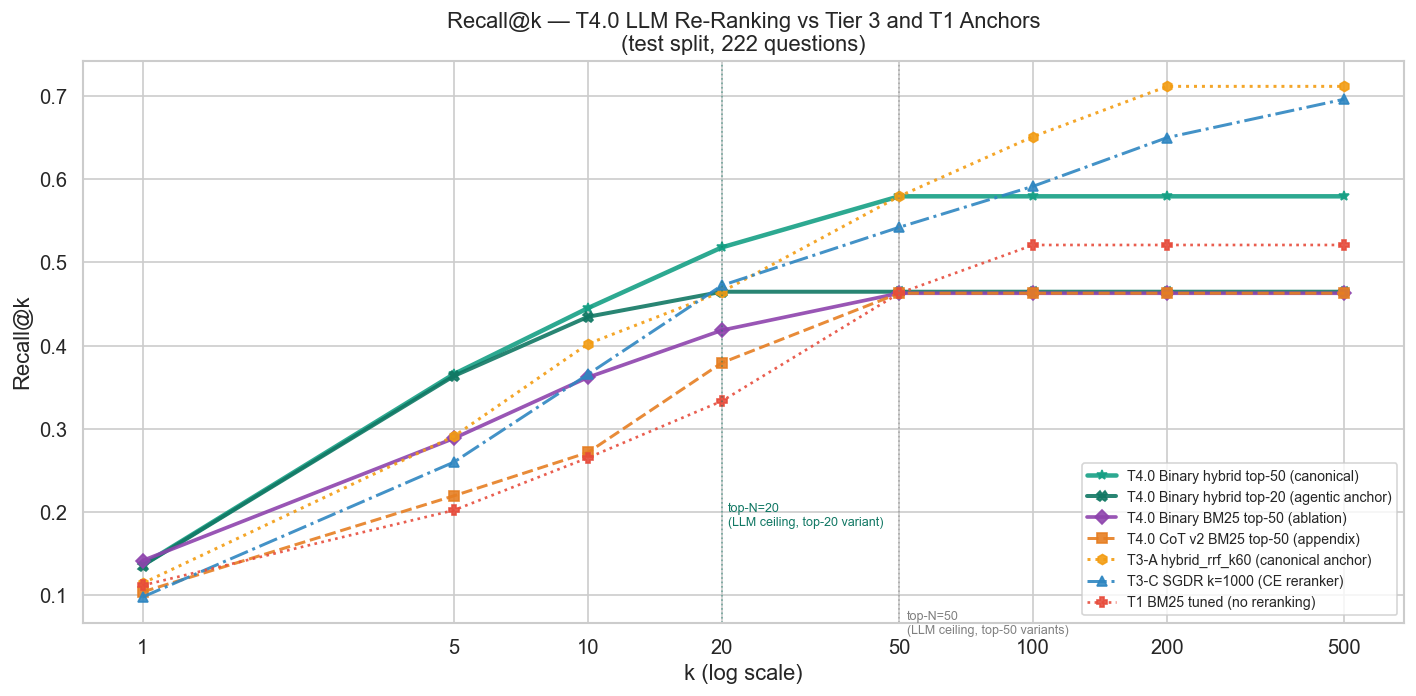

Notes:
  • All T4.0 variants plateau at R@k = R@first_stage_k for k ≥ first_stage_k.
    T4.0-hybrid-top50 (first_stage_k=100): plateau at R@50 = R@100 = 0.5795
    T4.0-hybrid-top20 (top_n=20):          plateau at R@20 = R@100 = 0.4648
    T4.0-BM25  (top_n=50, no padding):     plateau at R@50 = R@100 = 0.4630
  • T3-A hybrid_rrf_k60 anchor uses unbounded first-stage; that is why its R@100 keeps growing past T4.0-hybrid.


In [4]:
K_VALS = [1, 5, 10, 20, 50, 100, 200, 500]
K_COLS = [f'Recall@{k}' for k in K_VALS]

systems = [
    (hyb_binary_d,   'T4.0 Binary hybrid top-50 (canonical)',         COLOR_BINARY_HYB,   '-',  '*', 2.7),
    (hyb_binary20_d, 'T4.0 Binary hybrid top-20 (agentic anchor)',    COLOR_BINARY_HYB20, '-',  'X', 2.4),
    (binary_d,       'T4.0 Binary BM25 top-50 (ablation)',            COLOR_BINARY,       '-',  'D', 2.2),
    (num10_d,          'T4.0 0–10 numeric BM25 top-50 (appendix)',            COLOR_NUM10,          '--', 's', 1.8),
    (rrf_d,          'T3-A hybrid_rrf_k60 (canonical anchor)',        COLOR_RRF,          ':',  'h', 1.8),
    (sgdr_d,         'T3-C SGDR k=1000 (CE reranker)',                COLOR_SGDR,         '-.', '^', 1.8),
    (bm25_d,         'T1 BM25 tuned (no reranking)',                  COLOR_BM25,         ':',  'P', 1.6),
]

fig, ax = plt.subplots(figsize=(12, 6))
for d, label, color, ls, marker, lw in systems:
    ys = [m(d).get(c, 0) for c in K_COLS]
    ax.plot(K_VALS, ys, label=label, color=color, linewidth=lw,
            linestyle=ls, marker=marker, markersize=6, alpha=0.9)

ax.set_xscale('log')
ax.set_xlabel('k (log scale)')
ax.set_ylabel('Recall@k')
ax.set_title('Recall@k — T4.0 LLM Re-Ranking vs Tier 3 and T1 Anchors\n(test split, 222 questions)')
ax.set_xticks(K_VALS)
ax.set_xticklabels(K_VALS)
ax.legend(fontsize=8.5, loc='lower right')

# Annotate recall ceilings (top-N=50 and top-N=20)
ax.axvline(50, color='gray',  linestyle=':', linewidth=1, alpha=0.5)
ax.text(52, 0.05, 'top-N=50\n(LLM ceiling, top-50 variants)', fontsize=7.5, color='gray', va='bottom')
ax.axvline(20, color='#117864', linestyle=':', linewidth=1, alpha=0.5)
ax.text(20.6, 0.18, 'top-N=20\n(LLM ceiling, top-20 variant)', fontsize=7.5, color='#117864', va='bottom')

plt.tight_layout()
plt.savefig(IMG_DIR / 'recall_k_curves.png', bbox_inches='tight')
plt.show()

print('Notes:')
print('  • All T4.0 variants plateau at R@k = R@first_stage_k for k ≥ first_stage_k.')
print(f'    T4.0-hybrid-top50 (first_stage_k=100): plateau at R@50 = R@100 = {r100(hyb_binary_d):.4f}')
print(f'    T4.0-hybrid-top20 (top_n=20):          plateau at R@20 = R@100 = {r100(hyb_binary20_d):.4f}')
print(f'    T4.0-BM25  (top_n=50, no padding):     plateau at R@50 = R@100 = {r100(binary_d):.4f}')
print('  • T3-A hybrid_rrf_k60 anchor uses unbounded first-stage; that is why its R@100 keeps growing past T4.0-hybrid.')


## 2. R@10 Bar Chart — T4.0 vs Comparison Points

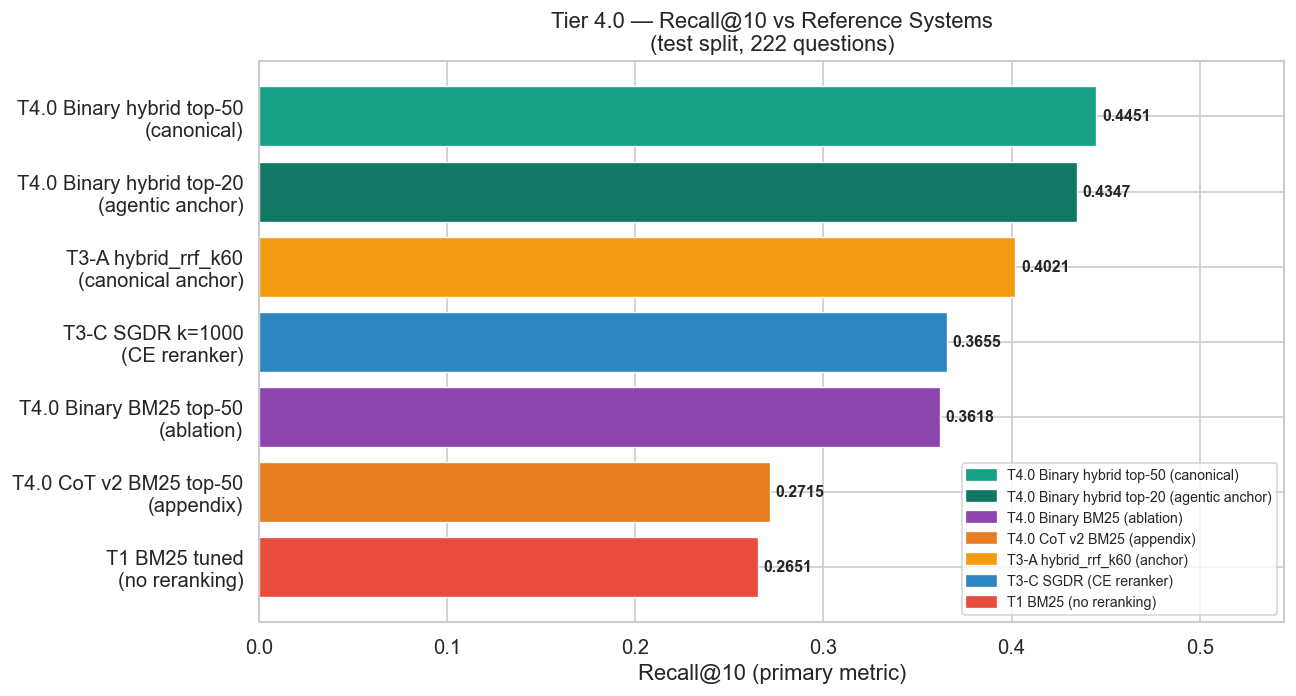

In [5]:
systems_bar = [
    ('T1 BM25 tuned\n(no reranking)',                  r10(bm25_d),         COLOR_BM25),
    ('T4.0 0–10 numeric BM25 top-50\n(appendix)',            r10(num10_d),          COLOR_NUM10),
    ('T4.0 Binary BM25 top-50\n(ablation)',            r10(binary_d),       COLOR_BINARY),
    ('T3-C SGDR k=1000\n(CE reranker)',                r10(sgdr_d),         COLOR_SGDR),
    ('T3-A hybrid_rrf_k60\n(canonical anchor)',        r10(rrf_d),          COLOR_RRF),
    ('T4.0 Binary hybrid top-20\n(agentic anchor)',    r10(hyb_binary20_d), COLOR_BINARY_HYB20),
    ('T4.0 Binary hybrid top-50\n(canonical)',         r10(hyb_binary_d),   COLOR_BINARY_HYB),
]
lbls = [s[0] for s in systems_bar]
vals = [s[1] for s in systems_bar]
cols = [s[2] for s in systems_bar]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(lbls, vals, color=cols, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, vals):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9.5, fontweight='bold')

ax.set_xlabel('Recall@10 (primary metric)')
ax.set_title('Tier 4.0 — Recall@10 vs Reference Systems\n(test split, 222 questions)')
ax.set_xlim(0, max(vals) + 0.10)

legend_items = [
    mpatches.Patch(color=COLOR_BINARY_HYB,    label='T4.0 Binary hybrid top-50 (canonical)'),
    mpatches.Patch(color=COLOR_BINARY_HYB20,  label='T4.0 Binary hybrid top-20 (agentic anchor)'),
    mpatches.Patch(color=COLOR_BINARY,        label='T4.0 Binary BM25 (ablation)'),
    mpatches.Patch(color=COLOR_NUM10,           label='T4.0 0–10 numeric BM25 (appendix)'),
    mpatches.Patch(color=COLOR_RRF,           label='T3-A hybrid_rrf_k60 (anchor)'),
    mpatches.Patch(color=COLOR_SGDR,          label='T3-C SGDR (CE reranker)'),
    mpatches.Patch(color=COLOR_BM25,          label='T1 BM25 (no reranking)'),
]
ax.legend(handles=legend_items, fontsize=8.5, loc='lower right')
plt.tight_layout()
plt.savefig(IMG_DIR / 'recall10_bar.png', bbox_inches='tight')
plt.show()


## 3. Binary vs 0–10 Numeric: Scoring Paradigm Comparison

Both use the same first-stage (`bm25_tuned_k11.5_b0.25`), same top-N=50, same LLaMA 3.1 8B.
The only axis of variation is the scoring prompt (binary Oui/Non vs chain-of-thought 0-10).
The hybrid first-stage variant only ran the binary prompt; it is treated separately in Sections 7 and 9
(first-stage pool quality effect).

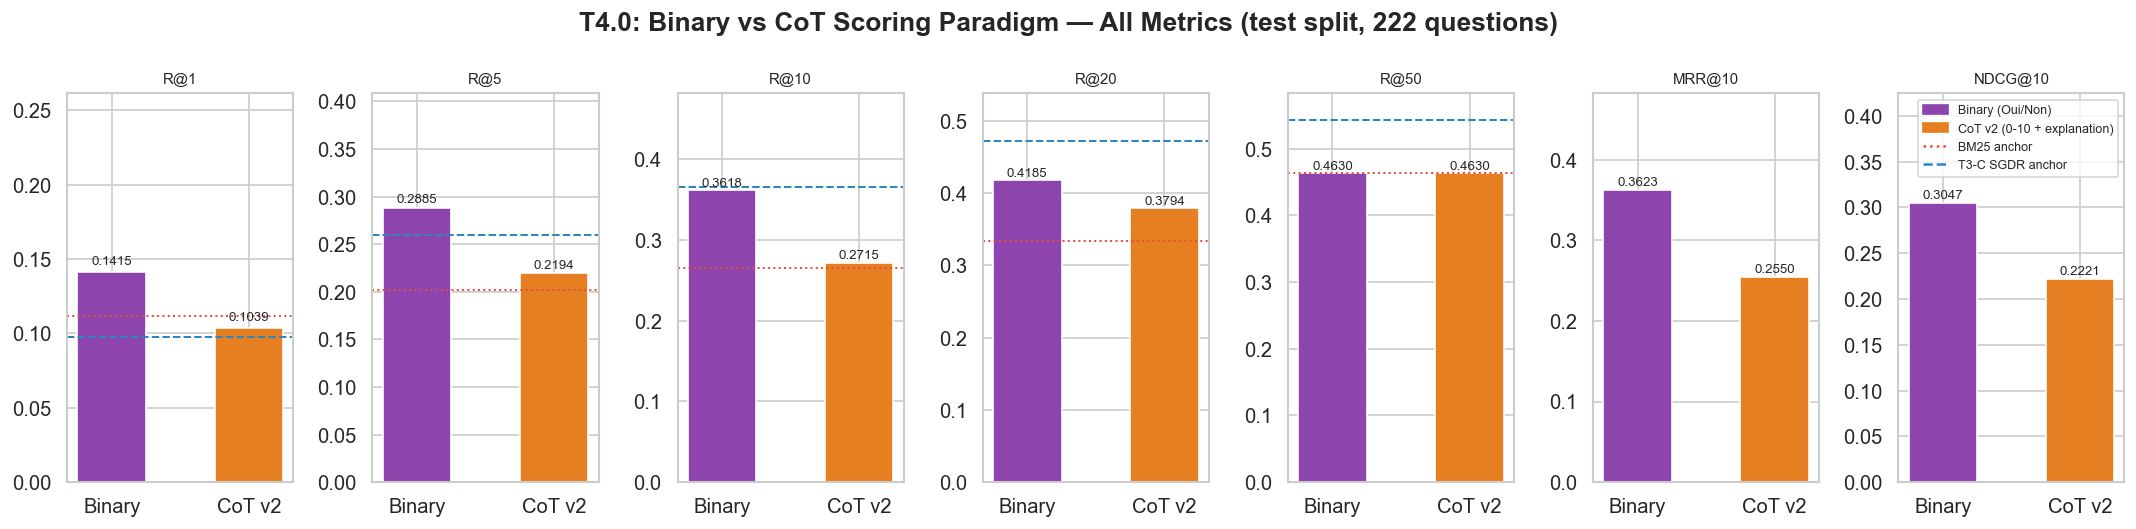

Metric,Binary,CoT v2,Δ (Binary − CoT)
Recall@1,0.1415,0.1039,+0.0376
Recall@5,0.2885,0.2194,+0.0691
Recall@10,0.3618,0.2715,+0.0903
Recall@20,0.4185,0.3794,+0.0391
Recall@50,0.4630,0.4630,+0.0000
MRR@10,0.3623,0.2550,+0.1073
NDCG@10,0.3047,0.2221,+0.0826


In [6]:
metrics_comp = ['Recall@1', 'Recall@5', 'Recall@10', 'Recall@20', 'Recall@50', 'MRR@10', 'NDCG@10']

fig, axes = plt.subplots(1, len(metrics_comp), figsize=(18, 4.5))
for ax, metric in zip(axes, metrics_comp):
    vals   = [m(binary_d).get(metric, 0), m(num10_d).get(metric, 0)]
    colors = [COLOR_BINARY, COLOR_NUM10]
    lbls   = ['Binary', '0–10 numeric']
    bars = ax.bar(lbls, vals, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=8)

    # Anchors for R@ metrics
    if 'Recall' in metric:
        k = int(metric.split('@')[1])
        bm25_ref = m(bm25_d).get(metric, 0)
        sgdr_ref = m(sgdr_d).get(metric, 0)
        ax.axhline(bm25_ref, color=COLOR_BM25,  linestyle=':', linewidth=1.2,
                   label=f'BM25 ({bm25_ref:.4f})')
        ax.axhline(sgdr_ref, color=COLOR_SGDR, linestyle='--', linewidth=1.2,
                   label=f'SGDR ({sgdr_ref:.4f})')

    short = metric.replace('Recall@', 'R@').replace('MRR@10', 'MRR@10').replace('NDCG@10', 'NDCG@10')
    ax.set_title(short, fontsize=9)
    ax.set_ylim(0, max(vals) + 0.12)

legend_items = [
    mpatches.Patch(color=COLOR_BINARY, label='Binary (Oui/Non)'),
    mpatches.Patch(color=COLOR_NUM10,    label='0–10 numeric (0-10 + explanation)'),
    plt.Line2D([0],[0], color=COLOR_BM25, linestyle=':', label='BM25 anchor'),
    plt.Line2D([0],[0], color=COLOR_SGDR, linestyle='--', label='T3-C SGDR anchor'),
]
axes[-1].legend(handles=legend_items, fontsize=7.5, loc='upper right')
plt.suptitle('T4.0: Binary vs 0–10 numeric Scoring Paradigm — All Metrics (test split, 222 questions)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'binary_vs_0to10.png', bbox_inches='tight')
plt.show()

# Delta table
delta_rows = []
for metric in metrics_comp:
    b = m(binary_d).get(metric, 0)
    c = m(num10_d).get(metric, 0)
    delta_rows.append({'Metric': metric, 'Binary': b, '0–10 numeric': c, 'Δ (Binary − 0–10)': b - c})
delta_df = pd.DataFrame(delta_rows)
display(delta_df.style.format(
    {'Binary': '{:.4f}', '0–10 numeric': '{:.4f}', 'Δ (Binary − 0–10)': '{:+.4f}'}
).hide(axis='index').bar(subset=['Δ (Binary − 0–10)'], align='zero', color=['#e74c3c','#27ae60']))

## 4. Score Diagnostics — Score Distribution and Parse Failures

In [7]:
# ── Score diagnostics comparison ───────────────────────────────────────────
# Note: hybrid runs did not capture per-query score diagnostics — only run-level stats.
diag_binary = binary_d['score_diagnostics']
diag_num10    = num10_d['score_diagnostics']
stat_binary  = binary_d['llm_rerank_stats']
stat_hyb     = hyb_binary_d['llm_rerank_stats']
stat_hyb20   = hyb_binary20_d['llm_rerank_stats']
stat_num10     = num10_d['llm_rerank_stats']

diag_df = pd.DataFrame([
    {
        'Variant':                       'Binary BM25 (Oui/Non)',
        'Mean score (per-query mean)':   diag_binary['mean_score_per_query_mean'],
        'Score std (per-query mean)':    diag_binary['score_std_per_query_mean'],
        'Frac queries all-same score':   diag_binary['fraction_queries_all_same_score'],
        'Parse failure rate':            stat_binary['parse_failure_rate'],
        'Cache size after run':          stat_binary['cache_size_after_run'],
    },
    {
        'Variant':                       'Binary hybrid top-50 (canonical)',
        'Mean score (per-query mean)':   None,
        'Score std (per-query mean)':    None,
        'Frac queries all-same score':   None,
        'Parse failure rate':            stat_hyb['parse_failure_rate'],
        'Cache size after run':          stat_hyb['cache_size_after_run'],
    },
    {
        'Variant':                       'Binary hybrid top-20 (agentic anchor)',
        'Mean score (per-query mean)':   None,
        'Score std (per-query mean)':    None,
        'Frac queries all-same score':   None,
        'Parse failure rate':            stat_hyb20['parse_failure_rate'],
        'Cache size after run':          stat_hyb20['cache_size_after_run'],
    },
    {
        'Variant':                       '0–10 numeric BM25 (legacy )',
        'Mean score (per-query mean)':   diag_num10['mean_score_per_query_mean'],
        'Score std (per-query mean)':    diag_num10['score_std_per_query_mean'],
        'Frac queries all-same score':   diag_num10['fraction_queries_all_same_score'],
        'Parse failure rate':            stat_num10['parse_failure_rate'],
        'Cache size after run':          stat_num10['cache_size_after_run'],
    },
])

print('Score diagnostics:')
print('  Note: per-query score diagnostics were not captured in the hybrid runs; only run-level stats shown.')
display(diag_df.style.format({
    'Mean score (per-query mean)':  '{:.4f}',
    'Score std (per-query mean)':   '{:.4f}',
    'Frac queries all-same score':  '{:.4f}',
    'Parse failure rate':           '{:.4f}',
}, na_rep='—').hide(axis='index'))

print(f'\nBinary BM25: mean={diag_binary["mean_score_per_query_mean"]:.4f} (≈ Oui rate per query)')
print(f'  → 18.2% of candidates scored Oui (relevant) per query on average')
print(f'  → {diag_binary["fraction_queries_all_same_score"]*100:.1f}% of queries got all-same scores (no re-ranking occurs)')
print(f'\nBinary hybrid top-50: parse_failure_rate={stat_hyb["parse_failure_rate"]:.4f}')
print(f'Binary hybrid top-20: parse_failure_rate={stat_hyb20["parse_failure_rate"]:.4f}  '
      f'(same scoring paradigm — no calibration/safety-filter issues expected)')
print(f'\n0–10 numeric BM25: mean score={diag_num10["mean_score_per_query_mean"]:.2f}/10, '
      f'std={diag_num10["score_std_per_query_mean"]:.4f}')
print(f'  → Parse failure rate: {stat_num10["parse_failure_rate"]*100:.1f}% (safety filter; legal-domain system prompt applied)')


Score diagnostics:
  Note: per-query score diagnostics were not captured in the hybrid runs; only run-level stats shown.


Variant,Mean score (per-query mean),Score std (per-query mean),Frac queries all-same score,Parse failure rate,Cache size after run
Binary BM25 (Oui/Non),0.1819,0.3353,0.0495,0.0000,12952
Binary hybrid top-50 (canonical),—,—,—,0.0000,16381
Binary hybrid top-20 (agentic anchor),—,—,—,0.0000,16381
CoT v2 BM25 (0-10 + explanation),5.3300,1.5920,0.0000,0.0144,11100



Binary BM25: mean=0.1819 (≈ Oui rate per query)
  → 18.2% of candidates scored Oui (relevant) per query on average
  → 5.0% of queries got all-same scores (no re-ranking occurs)

Binary hybrid top-50: parse_failure_rate=0.0000
Binary hybrid top-20: parse_failure_rate=0.0000  (same scoring paradigm — no calibration/safety-filter issues expected)

CoT BM25: mean score=5.33/10, std=1.5920
  → Parse failure rate: 1.4% (safety filter; legal-domain system prompt applied)


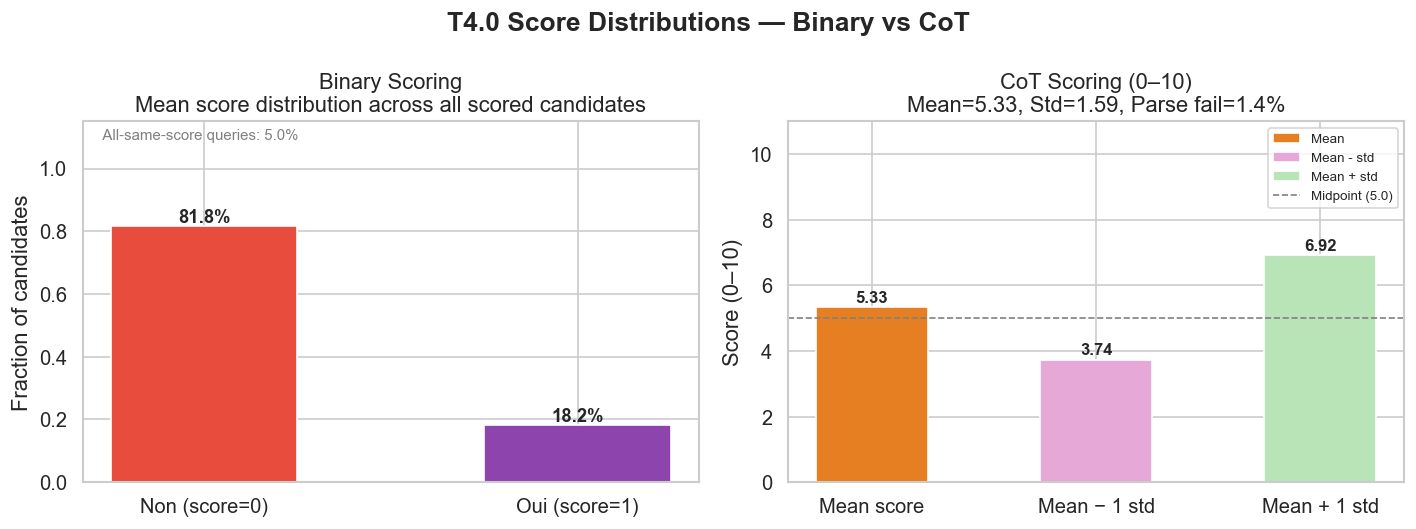

In [8]:
# ── Score distribution visualisation ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Binary: fraction of Oui vs Non (mean_score = Oui rate)
ax = axes[0]
oui_rate  = diag_binary['mean_score_per_query_mean']   # ≈ 18.2%
non_rate  = 1.0 - oui_rate
bars = ax.bar(['Non (score=0)', 'Oui (score=1)'], [non_rate, oui_rate],
              color=[COLOR_BM25, COLOR_BINARY], edgecolor='white', width=0.5)
for bar, val in zip(bars, [non_rate, oui_rate]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Fraction of candidates')
ax.set_title('Binary Scoring\nMean score distribution across all scored candidates')
ax.set_ylim(0, 1.15)
ax.annotate(f'  All-same-score queries: {diag_binary["fraction_queries_all_same_score"]*100:.1f}%',
            xy=(0.02, 0.95), xycoords='axes fraction', fontsize=9, color='gray')

# 0–10 numeric: show mean, ±1 std, and parse failure rate as separate bar
ax = axes[1]
mu  = diag_num10['mean_score_per_query_mean']
std = diag_num10['score_std_per_query_mean']
pfr = stat_num10['parse_failure_rate']

x  = np.arange(3)
ys = [mu, mu - std, mu + std]
ax.bar(x, ys, color=[COLOR_NUM10, '#e6a8d7', '#b8e4b8'],
       edgecolor='white', width=0.5, label=['Mean', 'Mean - std', 'Mean + std'])
ax.axhline(5, color='gray', linestyle='--', linewidth=1, label='Midpoint (5.0)')
ax.set_xticks(x)
ax.set_xticklabels(['Mean score', 'Mean − 1 std', 'Mean + 1 std'])
ax.set_ylabel('Score (0–10)')
ax.set_title(f'0–10 Numeric Scoring\nMean={mu:.2f}, Std={std:.2f}, Parse fail={pfr*100:.1f}%')
ax.set_ylim(0, 11)
for xi, val in zip(x, ys):
    ax.text(xi, val + 0.15, f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('T4.0 Score Distributions — Binary vs 0–10 numeric', fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'score_distributions.png', bbox_inches='tight')
plt.show()

## 5. Latency Analysis — LLM Scoring Dominates

In [9]:
# ── Latency breakdown ──────────────────────────────────────────────────────
# IMPORTANT: T4.0-hybrid (both top-50 and top-20) latencies are artificially low
# because most articles in the hybrid first-stage pool were already scored during
# prior runs. Cache reuse: by the time the top-20 hybrid run executed, the score
# cache already contained ~16,400 (qid, aid) entries from the top-50 BM25 and
# top-50 hybrid runs; the top-20 hybrid run effectively made zero fresh LLM calls.
lat_data = [
    ('Binary hybrid top-50 (canonical)',      hyb_binary_d),
    ('Binary hybrid top-20 (agentic anchor)', hyb_binary20_d),
    ('Binary BM25   (ablation)',              binary_d),
    ('0–10 numeric BM25   (appendix)',              num10_d),
]

lat_rows = []
for label, d in lat_data:
    met  = d['metrics']
    lbd  = d['latency_breakdown_ms_mean']
    dist = d['latency_distribution']
    lat_rows.append({
        'Variant':          label,
        'Mean (s)':         met['T0/latency_mean_ms'] / 1000,
        'Std (s)':          met.get('T0/latency_std_ms', 0) / 1000,
        'p50 (s)':          dist['p50'] / 1000,
        'p90 (s)':          dist['p90'] / 1000,
        'p99 (s)':          dist.get('p99', dist.get('p95', 0)) / 1000,
        'Min (s)':          dist['min'] / 1000,
        'Max (s)':          dist['max'] / 1000,
        'First-stage (ms)': lbd['first_stage'],
        'LLM scoring (ms)': lbd['llm_scoring'],
        'LLM% of total':    lbd['llm_scoring'] / met['T0/latency_mean_ms'] * 100,
    })

lat_df = pd.DataFrame(lat_rows)
display(lat_df.style.format({
    'Mean (s)': '{:.2f}', 'Std (s)': '{:.2f}',
    'p50 (s)': '{:.2f}', 'p90 (s)': '{:.2f}', 'p99 (s)': '{:.2f}',
    'Min (s)': '{:.2f}', 'Max (s)': '{:.2f}',
    'First-stage (ms)': '{:.1f}', 'LLM scoring (ms)': '{:.1f}',
    'LLM% of total': '{:.2f}%',
}).hide(axis='index'))

# Cache-reuse diagnostics
hyb_cache    = hyb_binary_d['llm_rerank_stats']['cache_size_after_run']
hyb20_cache  = hyb_binary20_d['llm_rerank_stats']['cache_size_after_run']
bin_cache    = binary_d['llm_rerank_stats']['cache_size_after_run']
fresh_hyb    = hyb_cache - bin_cache
fresh_hyb20  = max(0, hyb20_cache - hyb_cache)
print('\nCache-reuse caveat (Binary hybrid runs):')
print(f'  BM25 binary run cache size:        {bin_cache:,} pairs')
print(f'  Hybrid top-50 run cache size:      {hyb_cache:,} pairs ({fresh_hyb:,} fresh LLM calls)')
print(f'  Hybrid top-20 run cache size:      {hyb20_cache:,} pairs ({fresh_hyb20:,} fresh LLM calls)')
print('  → Hybrid latencies are reduced by partial/complete cache hits.')
print('    Top-20 hybrid in particular ran with ~100% cache coverage — reported latency')
print('    reflects first-stage retrieval almost exclusively (LLM scoring ≈ 0 ms).')
print('    Not a clean per-call benchmark for the hybrid pool.')


Variant,Mean (s),Std (s),p50 (s),p90 (s),p99 (s),Min (s),Max (s),First-stage (ms),LLM scoring (ms),LLM% of total
Binary hybrid top-50 (canonical),8.26,2.38,8.06,11.21,15.88,2.96,16.70,70.6,8184.5,99.14%
Binary hybrid top-20 (agentic anchor),0.08,0.02,0.07,0.10,0.14,0.04,0.17,77.3,0.0,0.04%
Binary BM25 (ablation),31.25,6.75,30.51,41.49,48.21,14.17,51.65,45.9,31207.7,99.85%
CoT v2 BM25 (appendix),75.09,5.28,74.81,82.22,86.64,61.55,89.12,46.5,75046.1,99.94%



Cache-reuse caveat (Binary hybrid runs):
  BM25 binary run cache size:        12,952 pairs
  Hybrid top-50 run cache size:      16,381 pairs (3,429 fresh LLM calls)
  Hybrid top-20 run cache size:      16,381 pairs (0 fresh LLM calls)
  → Hybrid latencies are reduced by partial/complete cache hits.
    Top-20 hybrid in particular ran with ~100% cache coverage — reported latency
    reflects first-stage retrieval almost exclusively (LLM scoring ≈ 0 ms).
    Not a clean per-call benchmark for the hybrid pool.


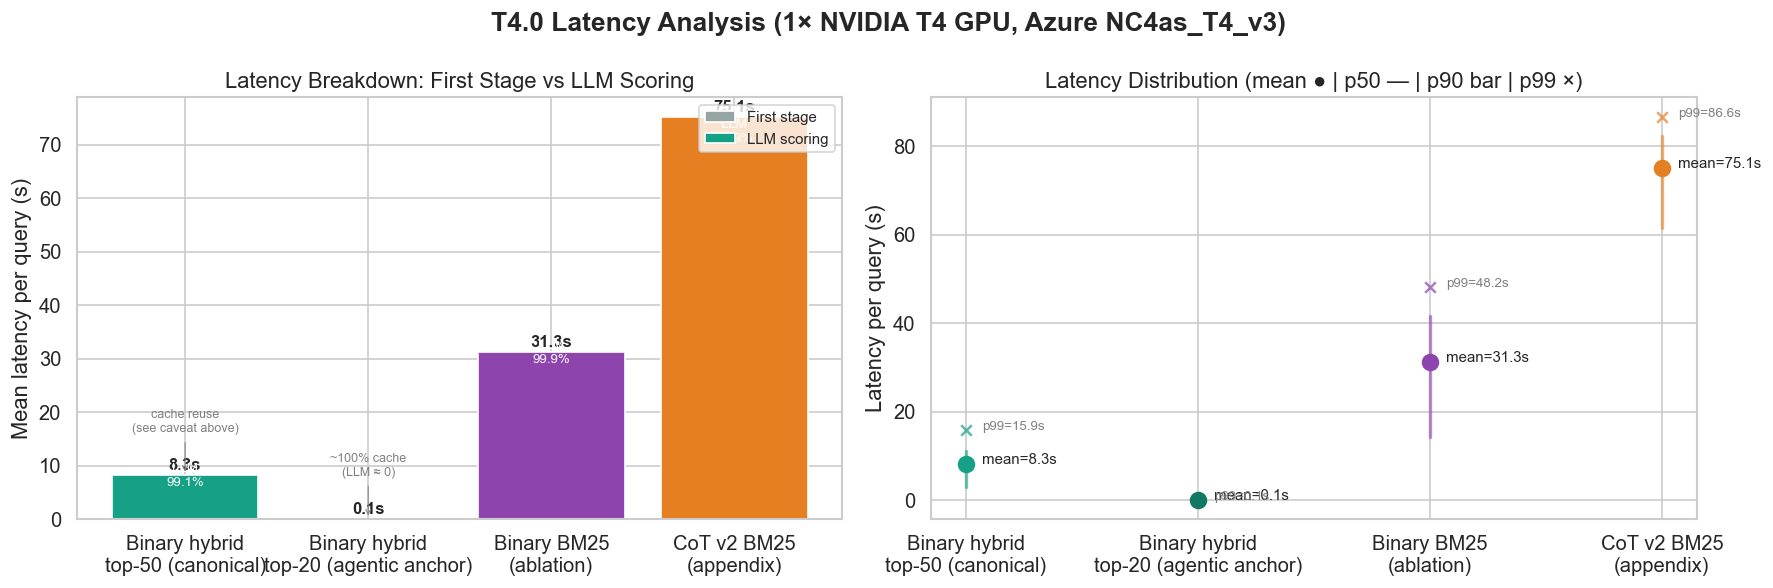


Latency comparison:
  T1 BM25 (no reranking):                       76.1ms / query
  T3-A hybrid_rrf_k60 (hybrid base):            322ms / query
  T3-C SGDR k=1000 (CE rerank):                 336ms / query
  T4.0 Binary BM25 (LLM, top-50):               31.3s   / query
  T4.0 Binary hybrid (LLM, top-50):             8.3s    / query  [partial cache reuse]
  T4.0 Binary hybrid (LLM, top-20):             0.08s   / query  [~100% cache reuse]
  T4.0 CoT v2 BM25 (LLM, top-50):               75.1s  / query


In [10]:
# ── Latency breakdown stacked bar ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: stacked breakdown (first stage vs LLM)
ax = axes[0]
variants_data = [
    ('Binary hybrid\ntop-50 (canonical)',     hyb_binary_d,   COLOR_BINARY_HYB),
    ('Binary hybrid\ntop-20 (agentic anchor)', hyb_binary20_d, COLOR_BINARY_HYB20),
    ('Binary BM25\n(ablation)',               binary_d,       COLOR_BINARY),
    ('0–10 numeric BM25\n(appendix)',               num10_d,          COLOR_NUM10),
]
variants = [v[0] for v in variants_data]
fs_ms = [v[1]['latency_breakdown_ms_mean']['first_stage'] for v in variants_data]
llm_ms = [v[1]['latency_breakdown_ms_mean']['llm_scoring'] for v in variants_data]
fs_s = [v / 1000 for v in fs_ms]
llm_s = [v / 1000 for v in llm_ms]
colors_v = [v[2] for v in variants_data]

x = np.arange(len(variants_data))
ax.bar(x, fs_s,  label='First stage', color='#95a5a6', edgecolor='white')
ax.bar(x, llm_s, bottom=fs_s, label='LLM scoring', color=colors_v, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(variants)
ax.set_ylabel('Mean latency per query (s)')
ax.set_title('Latency Breakdown: First Stage vs LLM Scoring')
ax.legend(fontsize=9, loc='upper right')
for xi, (fs, llm) in enumerate(zip(fs_s, llm_s)):
    total = fs + llm
    ax.text(xi, total + 1.0, f'{total:.1f}s', ha='center', fontsize=10, fontweight='bold')
    if llm > 1:
        y_label = total - max(2.0, total * 0.06)
        ax.text(xi, y_label, f'LLM\n{llm/(fs+llm)*100:.1f}%',
                ha='center', fontsize=8, color='white')

# Note about cache reuse for the hybrid bars
ax.annotate('cache reuse\n(see caveat above)',
            xy=(0, fs_s[0] + llm_s[0]), xytext=(0, fs_s[0] + llm_s[0] + 8),
            fontsize=7.5, color='gray', ha='center',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.6))
ax.annotate('~100% cache\n(LLM ≈ 0)',
            xy=(1, fs_s[1] + llm_s[1]), xytext=(1, fs_s[1] + llm_s[1] + 8),
            fontsize=7.5, color='gray', ha='center',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.6))

# Right: latency distribution
ax = axes[1]
for i, (label, d, color) in enumerate(variants_data):
    dist = d['latency_distribution']
    mu   = dist['mean'] / 1000
    p50  = dist['p50']  / 1000
    p_lo = dist.get('min', 0) / 1000
    p90  = dist['p90']  / 1000
    p99  = dist.get('p99', dist.get('p95', 0)) / 1000
    ax.scatter([i], [mu], color=color, s=90, zorder=5)
    ax.plot([i, i], [p_lo, p90], color=color, linewidth=2, alpha=0.6)
    ax.scatter([i], [p50], color=color, s=50, marker='_', zorder=5, linewidths=3)
    ax.scatter([i], [p99], color=color, s=40, marker='x', zorder=5, alpha=0.7)
    ax.annotate(f'mean={mu:.1f}s', (i + 0.07, mu), fontsize=9)
    ax.annotate(f'p99={p99:.1f}s', (i + 0.07, p99), fontsize=8, color='gray')

ax.set_xticks(range(len(variants_data)))
ax.set_xticklabels(variants)
ax.set_ylabel('Latency per query (s)')
ax.set_title('Latency Distribution (mean ● | p50 — | p90 bar | p99 ×)')

plt.suptitle('T4.0 Latency Analysis (1× NVIDIA T4 GPU, Azure NC4as_T4_v3)', fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'latency_breakdown.png', bbox_inches='tight')
plt.show()

# Anchor latencies for context
print('\nLatency comparison:')
print(f'  T1 BM25 (no reranking):                       {m(bm25_d).get("T0/latency_mean_ms",0):.1f}ms / query')
print(f'  T3-A hybrid_rrf_k60 (hybrid base):            {m(rrf_d).get("T0/latency_mean_ms",0):.0f}ms / query')
print(f'  T3-C SGDR k=1000 (CE rerank):                 {m(sgdr_d).get("T0/latency_mean_ms",0):.0f}ms / query')
print(f'  T4.0 Binary BM25 (LLM, top-50):               {m(binary_d).get("T0/latency_mean_ms",0)/1000:.1f}s   / query')
print(f'  T4.0 Binary hybrid (LLM, top-50):             {m(hyb_binary_d).get("T0/latency_mean_ms",0)/1000:.1f}s    / query  [partial cache reuse]')
print(f'  T4.0 Binary hybrid (LLM, top-20):             {m(hyb_binary20_d).get("T0/latency_mean_ms",0)/1000:.2f}s   / query  [~100% cache reuse]')
print(f'  T4.0 0–10 numeric BM25 (LLM, top-50):               {m(num10_d).get("T0/latency_mean_ms",0)/1000:.1f}s  / query')


## 6. Pareto Front — Latency vs Recall@10 Across Tiers

This is the thesis cost-benefit plot (Chapter 4.5). One point per system.

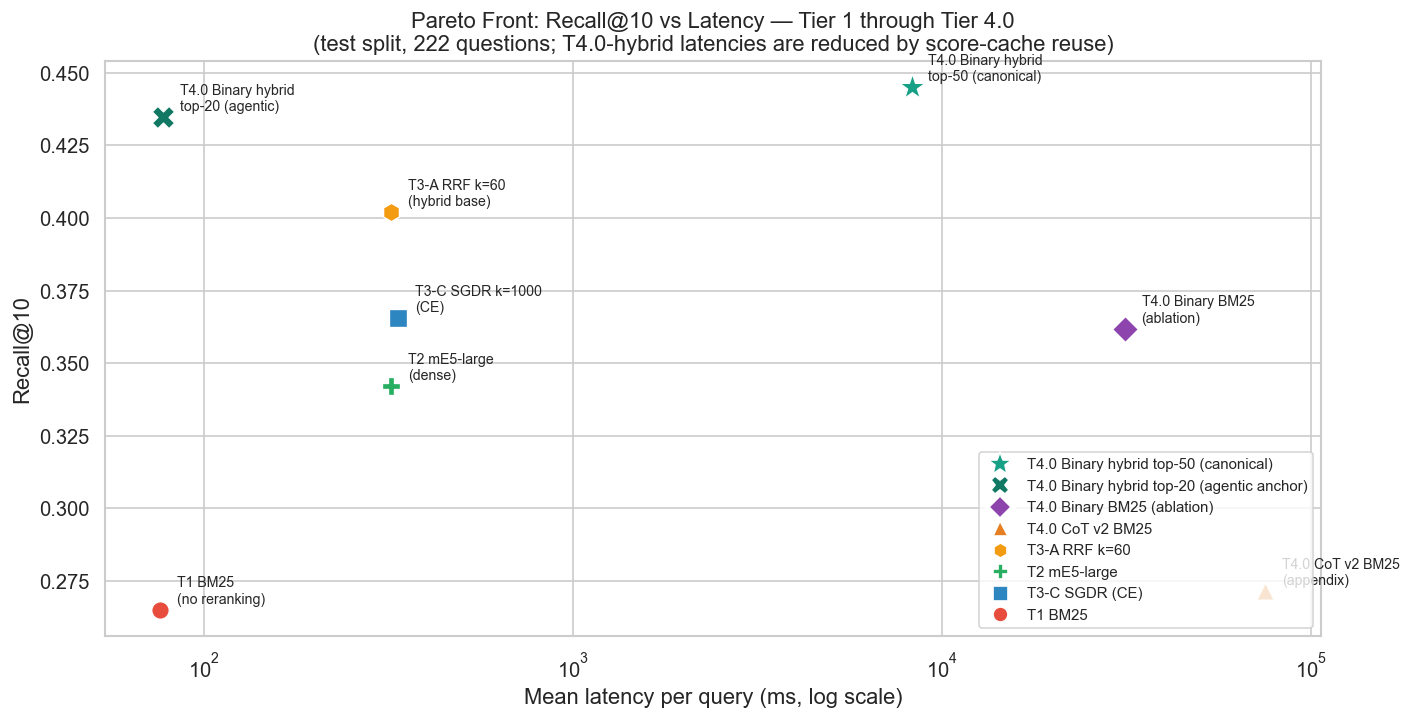

In [11]:
# dense_d and rrf_d already loaded in Cell 0004 (Setup)
pareto_systems = [
    ('T1 BM25\n(no reranking)',                bm25_d,         COLOR_BM25,         'o', 110),
    ('T3-C SGDR k=1000\n(CE)',                 sgdr_d,         COLOR_SGDR,         's', 120),
    ('T3-A RRF k=60\n(hybrid base)',           rrf_d,          COLOR_RRF,          'h', 120),
    ('T4.0 Binary BM25\n(ablation)',           binary_d,       COLOR_BINARY,       'D', 120),
    ('T4.0 Binary hybrid\ntop-50 (canonical)', hyb_binary_d,   COLOR_BINARY_HYB,   '*', 260),
    ('T4.0 Binary hybrid\ntop-20 (agentic)',   hyb_binary20_d, COLOR_BINARY_HYB20, 'X', 180),
    ('T4.0 0–10 numeric BM25\n(appendix)',           num10_d,          COLOR_NUM10,          '^', 110),
]
if dense_d:
    pareto_systems.insert(2, ('T2 mE5-large\n(dense)',  dense_d, COLOR_DENSE, 'P', 110))

fig, ax = plt.subplots(figsize=(12, 6.2))
for label, d, color, marker, sz in pareto_systems:
    lat_ms   = m(d).get('T0/latency_mean_ms', 0)
    recall10 = m(d).get('Recall@10', 0)
    ax.scatter(lat_ms, recall10, color=color, s=sz, marker=marker, zorder=4,
               edgecolors='white', linewidth=0.8)
    ax.annotate(label, (lat_ms, recall10),
                textcoords='offset points', xytext=(10, 4), fontsize=8.5)

ax.set_xscale('log')
ax.set_xlabel('Mean latency per query (ms, log scale)')
ax.set_ylabel('Recall@10')
ax.set_title('Pareto Front: Recall@10 vs Latency — Tier 1 through Tier 4.0\n'
             '(test split, 222 questions; T4.0-hybrid latencies are reduced by score-cache reuse)')

legend_items = [
    plt.Line2D([0],[0], marker='*', color='w', markerfacecolor=COLOR_BINARY_HYB,   markersize=15, label='T4.0 Binary hybrid top-50 (canonical)'),
    plt.Line2D([0],[0], marker='X', color='w', markerfacecolor=COLOR_BINARY_HYB20, markersize=11, label='T4.0 Binary hybrid top-20 (agentic anchor)'),
    plt.Line2D([0],[0], marker='D', color='w', markerfacecolor=COLOR_BINARY,       markersize=9,  label='T4.0 Binary BM25 (ablation)'),
    plt.Line2D([0],[0], marker='^', color='w', markerfacecolor=COLOR_NUM10,          markersize=9,  label='T4.0 0–10 numeric BM25'),
    plt.Line2D([0],[0], marker='h', color='w', markerfacecolor=COLOR_RRF,          markersize=9,  label='T3-A RRF k=60'),
    plt.Line2D([0],[0], marker='s', color='w', markerfacecolor=COLOR_SGDR,         markersize=9,  label='T3-C SGDR (CE)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_BM25,         markersize=9,  label='T1 BM25'),
]
if dense_d:
    legend_items.insert(5, plt.Line2D([0],[0], marker='P', color='w', markerfacecolor=COLOR_DENSE, markersize=9, label='T2 mE5-large'))

ax.legend(handles=legend_items, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(IMG_DIR / 'pareto_front.png', bbox_inches='tight')
plt.show()


## 7. Significance Testing Summary

In [12]:
# ── Significance results loaded from result JSONs ─────────────────────────
sig_bm25_bin   = binary_d.get('significance_vs_anchor', {})
sig_hyb_pri    = hyb_binary_d.get('significance_vs_anchor', {})  # vs hybrid_rrf_k60
sig_hyb_sec    = (hyb_binary_d.get('secondary_significance', {})
                  .get('vs_llm_rerank_binary_top50_bm25_test', {}))
sig_hyb20_pri  = hyb_binary20_d.get('significance_vs_anchor', {})  # top-20 vs hybrid_rrf_k60
sig_hyb20_sec  = (hyb_binary20_d.get('secondary_significance', {})
                  .get('vs_llm_rerank_binary_top50_hybrid_rrf_k60_test', {}))  # top-20 vs top-50 hybrid
sig_num10        = num10_d.get('significance_vs_anchor', {})

print('Significance tests: paired t-test on per-query Recall@10')
print('All p-values are pre-computed in the experiment result JSONs.')
print()

sig_rows = [
    {
        'Comparison':  'T4.0 Binary hybrid top-50  vs  T3-A hybrid_rrf_k60   [PRIMARY top-50]',
        'System R@10': r10(hyb_binary_d),
        'Anchor R@10': r10(rrf_d),
        'Δ R@10':      r10(hyb_binary_d) - r10(rrf_d),
        'p (R@10)':    sig_hyb_pri.get('p_value_recall10'),
        'Significant': sig_hyb_pri.get('significant'),
        'Interpretation': 'LLM rerank value on hybrid pool (top-50)',
    },
    {
        'Comparison':  'T4.0 Binary hybrid top-20  vs  T3-A hybrid_rrf_k60   [PRIMARY top-20]',
        'System R@10': r10(hyb_binary20_d),
        'Anchor R@10': r10(rrf_d),
        'Δ R@10':      r10(hyb_binary20_d) - r10(rrf_d),
        'p (R@10)':    sig_hyb20_pri.get('p_value_recall10'),
        'Significant': sig_hyb20_pri.get('significant'),
        'Interpretation': 'LLM rerank value on hybrid pool (agentic-matched top-20)',
    },
    {
        'Comparison':  'T4.0 Binary hybrid top-20  vs  T4.0 Binary hybrid top-50   [POOL-SIZE]',
        'System R@10': r10(hyb_binary20_d),
        'Anchor R@10': r10(hyb_binary_d),
        'Δ R@10':      r10(hyb_binary20_d) - r10(hyb_binary_d),
        'p (R@10)':    sig_hyb20_sec.get('p_value_recall10'),
        'Significant': sig_hyb20_sec.get('significant'),
        'Interpretation': 'Pool-size effect (same scorer, same first stage)',
    },
    {
        'Comparison':  'T4.0 Binary hybrid top-50  vs  T4.0 Binary BM25      [POOL QUALITY]',
        'System R@10': r10(hyb_binary_d),
        'Anchor R@10': r10(binary_d),
        'Δ R@10':      r10(hyb_binary_d) - r10(binary_d),
        'p (R@10)':    sig_hyb_sec.get('p_value_recall10'),
        'Significant': sig_hyb_sec.get('significant'),
        'Interpretation': 'Pool quality effect (same scorer)',
    },
    {
        'Comparison':  'T4.0 Binary BM25    vs  T1 BM25 anchor',
        'System R@10': r10(binary_d),
        'Anchor R@10': r10(bm25_d),
        'Δ R@10':      r10(binary_d) - r10(bm25_d),
        'p (R@10)':    sig_bm25_bin.get('p_value_recall10'),
        'Significant': sig_bm25_bin.get('significant'),
        'Interpretation': 'LLM rerank value on BM25 pool',
    },
    {
        'Comparison':  'T4.0 0–10 numeric BM25    vs  T1 BM25 anchor',
        'System R@10': r10(num10_d),
        'Anchor R@10': r10(bm25_d),
        'Δ R@10':      r10(num10_d) - r10(bm25_d),
        'p (R@10)':    sig_num10.get('p_value_recall10'),
        'Significant': sig_num10.get('significant'),
        'Interpretation': 'Appendix — 0–10 numeric scorer',
    },
]

sig_df = pd.DataFrame(sig_rows)
display(sig_df.style.format({
    'System R@10': '{:.4f}', 'Anchor R@10': '{:.4f}',
    'Δ R@10': '{:+.4f}', 'p (R@10)': '{:.4f}',
}, na_rep='—').hide(axis='index'))

print('\nKey takeaways:')
p_pri   = sig_hyb_pri.get('p_value_recall10', 1)
p_sec   = sig_hyb_sec.get('p_value_recall10', 1)
p_pri20 = sig_hyb20_pri.get('p_value_recall10', 1)
p_pool  = sig_hyb20_sec.get('p_value_recall10', 1)
print(f'  • PRIMARY top-50 (T4.0 Binary hybrid top-50 vs T3-A hybrid_rrf_k60):')
print(f'      Δ R@10 = +{r10(hyb_binary_d) - r10(rrf_d):.4f}, p = {p_pri:.4f} → '
      f'{"SIGNIFICANT" if sig_hyb_pri.get("significant") else "not significant"}')
print(f'  • PRIMARY top-20 (T4.0 Binary hybrid top-20 vs T3-A hybrid_rrf_k60):')
print(f'      Δ R@10 = +{r10(hyb_binary20_d) - r10(rrf_d):.4f}, p = {p_pri20:.4f} → '
      f'{"SIGNIFICANT" if sig_hyb20_pri.get("significant") else "not significant"}')
print(f'      → LLM re-ranking adds significant value at the agentic-matched top-20 pool size.')
print(f'  • POOL-SIZE (top-20 vs top-50, same scorer + first stage):')
print(f'      Δ R@10 = {r10(hyb_binary20_d) - r10(hyb_binary_d):+.4f}, p = {p_pool:.4f} → '
      f'{"SIGNIFICANT" if sig_hyb20_sec.get("significant") else "not significant"}')
print(f'      → The top-50 advantage at R@10 is not statistically detectable; the larger pool')
print(f'        mostly helps recall *beyond* k=20 (R@20: {r20(hyb_binary20_d):.4f} vs {r20(hyb_binary_d):.4f}).')
print(f'  • POOL QUALITY (T4.0 Binary hybrid top-50 vs T4.0 Binary BM25):')
print(f'      Δ R@10 = +{r10(hyb_binary_d) - r10(binary_d):.4f}, p = {p_sec:.4f} → '
      f'{"SIGNIFICANT" if sig_hyb_sec.get("significant") else "not significant"}')
print(f'  • For BM25 first stage: 0–10 numeric < Binary < SGDR(CE), all significant vs T1 BM25.')


Significance tests: paired t-test on per-query Recall@10
All p-values are pre-computed in the experiment result JSONs.



Comparison,System R@10,Anchor R@10,Δ R@10,p (R@10),Significant,Interpretation
T4.0 Binary hybrid top-50 vs T3-A hybrid_rrf_k60 [PRIMARY top-50],0.4451,0.4021,+0.0430,0.0162,True,LLM rerank value on hybrid pool (top-50)
T4.0 Binary hybrid top-20 vs T3-A hybrid_rrf_k60 [PRIMARY top-20],0.4347,0.4021,+0.0326,0.0065,True,LLM rerank value on hybrid pool (agentic-matched top-20)
T4.0 Binary hybrid top-20 vs T4.0 Binary hybrid top-50 [POOL-SIZE],0.4347,0.4451,-0.0104,0.4334,False,"Pool-size effect (same scorer, same first stage)"
T4.0 Binary hybrid top-50 vs T4.0 Binary BM25 [POOL QUALITY],0.4451,0.3618,+0.0833,0.0000,True,Pool quality effect (same scorer)
T4.0 Binary BM25 vs T1 BM25 anchor,0.3618,0.2651,+0.0967,0.0000,True,LLM rerank value on BM25 pool
T4.0 CoT v2 BM25 vs T1 BM25 anchor,0.2715,0.2651,+0.0064,—,—,Appendix — CoT scorer



Key takeaways:
  • PRIMARY top-50 (T4.0 Binary hybrid top-50 vs T3-A hybrid_rrf_k60):
      Δ R@10 = +0.0430, p = 0.0162 → SIGNIFICANT
  • PRIMARY top-20 (T4.0 Binary hybrid top-20 vs T3-A hybrid_rrf_k60):
      Δ R@10 = +0.0326, p = 0.0065 → SIGNIFICANT
      → LLM re-ranking adds significant value at the agentic-matched top-20 pool size.
  • POOL-SIZE (top-20 vs top-50, same scorer + first stage):
      Δ R@10 = -0.0104, p = 0.4334 → not significant
      → The top-50 advantage at R@10 is not statistically detectable; the larger pool
        mostly helps recall *beyond* k=20 (R@20: 0.4648 vs 0.5181).
  • POOL QUALITY (T4.0 Binary hybrid top-50 vs T4.0 Binary BM25):
      Δ R@10 = +0.0833, p = 0.0000 → SIGNIFICANT
  • For BM25 first stage: CoT < Binary < SGDR(CE), all significant vs T1 BM25.


## 8. Stratified Analysis — All T4.0 Variants vs Anchors

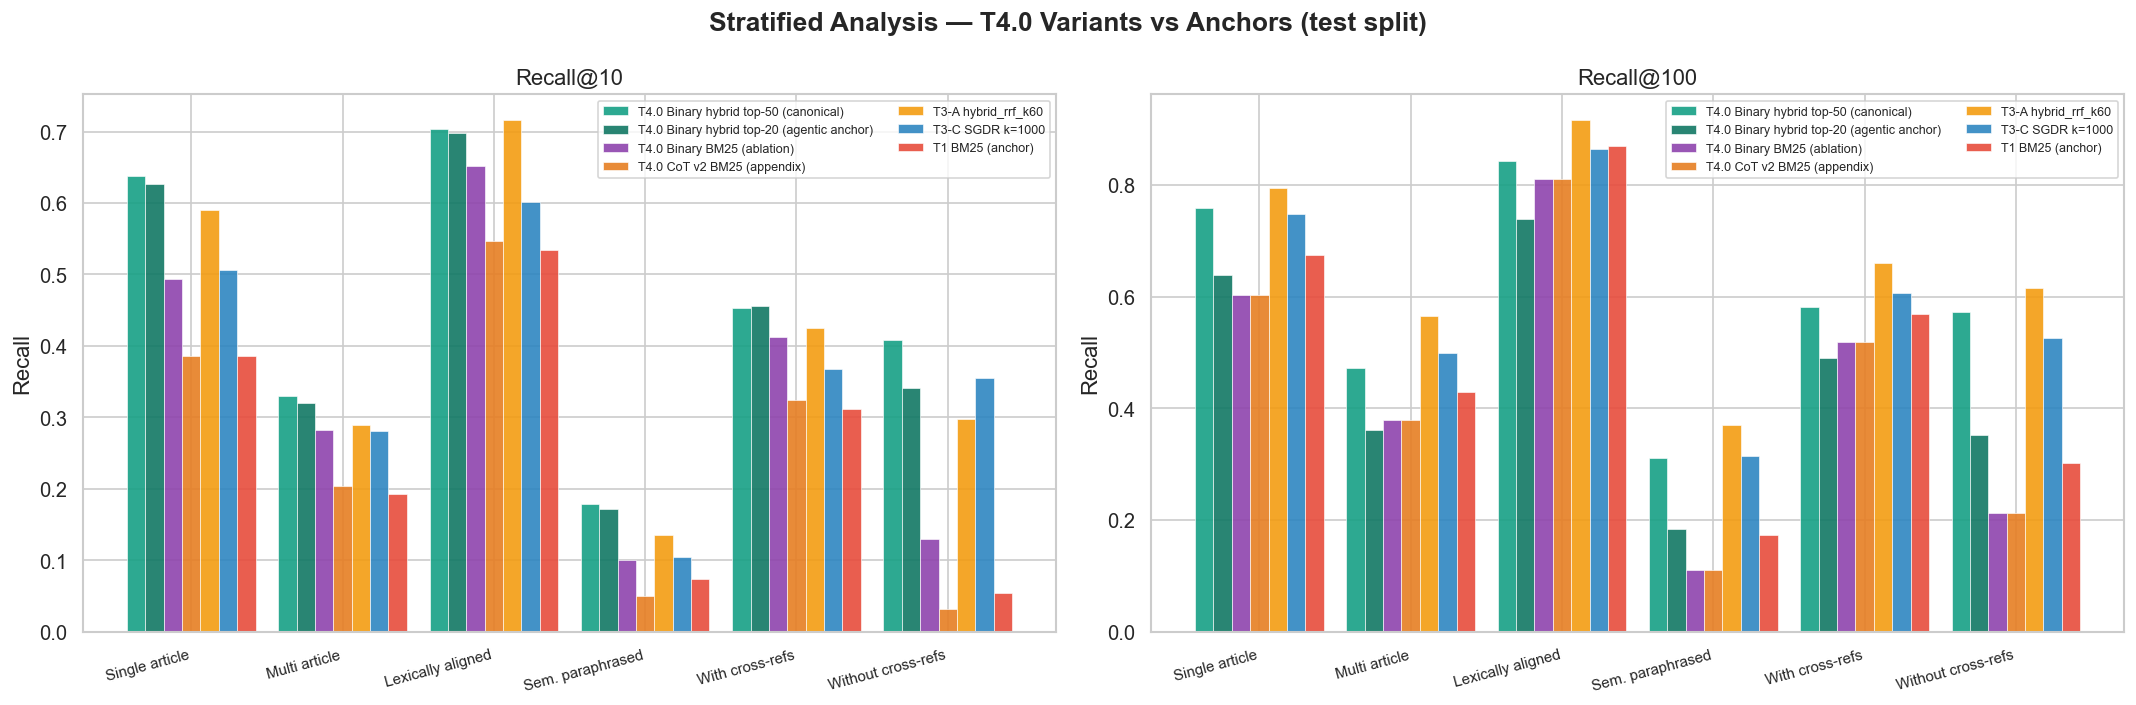

In [13]:
ALL_STRATA = [
    ('single_article',           'Single article'),
    ('multi_article',            'Multi article'),
    ('lexically_aligned',        'Lexically aligned'),
    ('semantically_paraphrased', 'Sem. paraphrased'),
    ('with_cross_refs',          'With cross-refs'),
    ('without_cross_refs',       'Without cross-refs'),
]

systems_strat = [
    ('T4.0 Binary hybrid top-50 (canonical)',      hyb_binary_d,   COLOR_BINARY_HYB),
    ('T4.0 Binary hybrid top-20 (agentic anchor)', hyb_binary20_d, COLOR_BINARY_HYB20),
    ('T4.0 Binary BM25 (ablation)',                binary_d,       COLOR_BINARY),
    ('T4.0 0–10 numeric BM25 (appendix)',                num10_d,          COLOR_NUM10),
    ('T3-A hybrid_rrf_k60',                        rrf_d,          COLOR_RRF),
    ('T3-C SGDR k=1000',                           sgdr_d,         COLOR_SGDR),
    ('T1 BM25 (anchor)',                           bm25_d,         COLOR_BM25),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, metric in zip(axes, ['Recall@10', 'Recall@100']):
    x = np.arange(len(ALL_STRATA))
    n = len(systems_strat)
    width = 0.85 / n
    for i, (label, d, color) in enumerate(systems_strat):
        vals = [d['stratified'].get(s, {}).get(metric, 0) for s, _ in ALL_STRATA]
        offset = (i - n/2 + 0.5) * width
        ax.bar(x + offset, vals, width, label=label, color=color,
               edgecolor='white', linewidth=0.4, alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels([lbl for _, lbl in ALL_STRATA], rotation=15, ha='right', fontsize=9)
    ax.set_title(metric); ax.set_ylabel('Recall')
    ax.legend(fontsize=7.5, ncol=2)

plt.suptitle('Stratified Analysis — T4.0 Variants vs Anchors (test split)', fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'stratified_all_systems.png', bbox_inches='tight')
plt.show()


In [14]:
# ── Strata numeric table ────────────────────────────────────────────────────
strat_rows = []
for stratum, label in ALL_STRATA:
    row = {'Stratum': label}
    for sys_label, d, _ in systems_strat:
        s_m = d['stratified'].get(stratum, {})
        row[f'{sys_label} R@10']  = s_m.get('Recall@10', 0)
        row[f'{sys_label} R@100'] = s_m.get('Recall@100', 0)
    strat_rows.append(row)

strat_df = pd.DataFrame(strat_rows)
fmt_cols = {c: '{:.4f}' for c in strat_df.columns if c != 'Stratum'}
display(strat_df.style.format(fmt_cols).hide(axis='index'))

Stratum,T4.0 Binary hybrid top-50 (canonical) R@10,T4.0 Binary hybrid top-50 (canonical) R@100,T4.0 Binary hybrid top-20 (agentic anchor) R@10,T4.0 Binary hybrid top-20 (agentic anchor) R@100,T4.0 Binary BM25 (ablation) R@10,T4.0 Binary BM25 (ablation) R@100,T4.0 CoT v2 BM25 (appendix) R@10,T4.0 CoT v2 BM25 (appendix) R@100,T3-A hybrid_rrf_k60 R@10,T3-A hybrid_rrf_k60 R@100,T3-C SGDR k=1000 R@10,T3-C SGDR k=1000 R@100,T1 BM25 (anchor) R@10,T1 BM25 (anchor) R@100
Single article,0.6386,0.7590,0.6265,0.6386,0.4940,0.6024,0.3855,0.6024,0.5904,0.7952,0.5060,0.7470,0.3855,0.6747
Multi article,0.3295,0.4723,0.3201,0.3610,0.2829,0.3797,0.2034,0.3797,0.2896,0.5654,0.2815,0.4988,0.1932,0.4292
Lexically aligned,0.7039,0.8425,0.6980,0.7384,0.6523,0.8113,0.5472,0.8113,0.7164,0.9164,0.6011,0.8644,0.5346,0.8690
Sem. paraphrased,0.1791,0.3117,0.1719,0.1839,0.1003,0.1096,0.0500,0.1096,0.1349,0.3693,0.1045,0.3146,0.0743,0.1723
With cross-refs,0.4531,0.5809,0.4552,0.4896,0.4127,0.5178,0.3243,0.5178,0.4251,0.6594,0.3677,0.6060,0.3114,0.5692
Without cross-refs,0.4086,0.5730,0.3411,0.3517,0.1301,0.2134,0.0314,0.2134,0.2971,0.6146,0.3551,0.5261,0.0542,0.3017


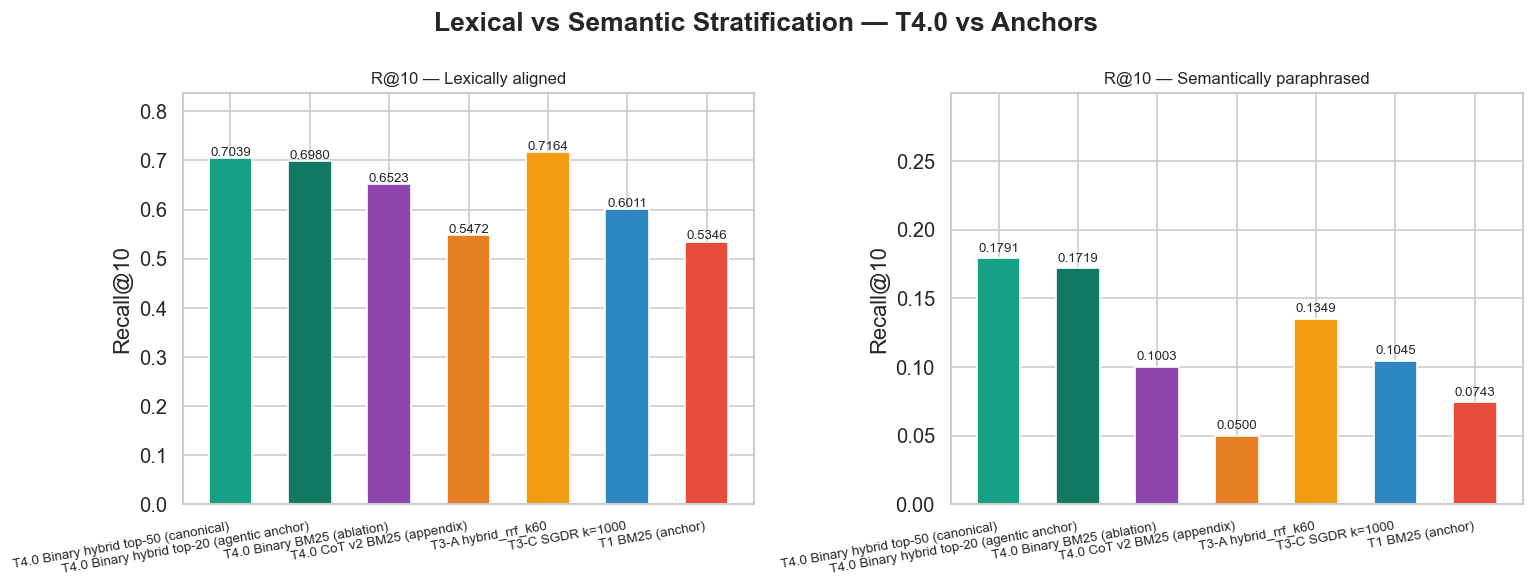

T4.0 Binary hybrid top-50 (canonical) lex=0.7039  sem=0.1791  gap=+0.5248
T4.0 Binary hybrid top-20 (agentic anchor) lex=0.6980  sem=0.1719  gap=+0.5261
T4.0 Binary BM25 (ablation)         lex=0.6523  sem=0.1003  gap=+0.5520
T4.0 CoT v2 BM25 (appendix)         lex=0.5472  sem=0.0500  gap=+0.4972
T3-A hybrid_rrf_k60                 lex=0.7164  sem=0.1349  gap=+0.5815
T3-C SGDR k=1000                    lex=0.6011  sem=0.1045  gap=+0.4967
T1 BM25 (anchor)                    lex=0.5346  sem=0.0743  gap=+0.4603


In [15]:
# ── Lexical vs semantic gap ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (stratum, label) in zip(axes, [
    ('lexically_aligned',        'Lexically aligned'),
    ('semantically_paraphrased', 'Semantically paraphrased'),
]):
    lbls  = [l for l, _, _ in systems_strat]
    vals  = [d['stratified'].get(stratum, {}).get('Recall@10', 0) for _, d, _ in systems_strat]
    cols  = [c for _, _, c in systems_strat]
    bars  = ax.bar(range(len(lbls)), vals, color=cols, edgecolor='white', width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=8)
    ax.set_xticks(range(len(lbls)))
    ax.set_xticklabels(lbls, rotation=10, ha='right', fontsize=8)
    ax.set_title(f'R@10 — {label}', fontsize=10)
    ax.set_ylabel('Recall@10')
    ax.set_ylim(0, max(vals) + 0.12)

plt.suptitle('Lexical vs Semantic Stratification — T4.0 vs Anchors', fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'stratified_lex_sem.png', bbox_inches='tight')
plt.show()

# Report lex/sem gap
for sys_label, d, _ in systems_strat:
    lex = d['stratified'].get('lexically_aligned', {}).get('Recall@10', 0)
    sem = d['stratified'].get('semantically_paraphrased', {}).get('Recall@10', 0)
    print(f'{sys_label:<35} lex={lex:.4f}  sem={sem:.4f}  gap={lex-sem:+.4f}')

## 9. Delta Comparison — T4.0 Canonical (hybrid binary) vs All Reference Points

In [16]:
# ── T4.0 Binary hybrid (canonical) vs each reference ───────────────────────
PRIMARY = hyb_binary_d
PRIMARY_LABEL = 'T4.0 Binary hybrid top-50 (canonical)'

refs = [
    ('vs T3-A hybrid_rrf_k60 (canonical anchor)',     rrf_d),
    ('vs T4.0 Binary hybrid top-20 (agentic anchor)', hyb_binary20_d),
    ('vs T4.0 Binary BM25 (pool quality ablation)',   binary_d),
    ('vs T1 BM25 anchor',                             bm25_d),
    ('vs T3-C SGDR k=1000 (CE rerank)',               sgdr_d),
    ('vs T4.0 0–10 numeric BM25 (scoring paradigm)',        num10_d),
]
if dense_d:
    refs.append(('vs T2 mE5-large concat_2x', dense_d))

comp_metrics = ['Recall@1', 'Recall@5', 'Recall@10', 'Recall@20', 'Recall@50', 'Recall@100',
                'MRR@10', 'NDCG@10', 'MAP@100']

print(f'{PRIMARY_LABEL}:')
print(f'  R@10={r10(PRIMARY):.4f}  R@100={r100(PRIMARY):.4f}  '
      f'MRR@10={mrr10(PRIMARY):.4f}\n')

for ref_label, ref_d in refs:
    print(f'\n{PRIMARY_LABEL}  {ref_label}:')
    for met in comp_metrics:
        delta = m(PRIMARY).get(met, 0) - m(ref_d).get(met, 0)
        arrow = '▲' if delta > 0 else ('▼' if delta < 0 else '=')
        print(f'  {met:<15} {delta:+.4f} {arrow}')

# ── Also: T4.0 Binary hybrid top-20 (agentic anchor) vs key refs ─────────────
PRIMARY20 = hyb_binary20_d
PRIMARY20_LABEL = 'T4.0 Binary hybrid top-20 (agentic anchor)'

refs20 = [
    ('vs T3-A hybrid_rrf_k60 (canonical anchor)',  rrf_d),
    ('vs T4.0 Binary hybrid top-50 (canonical)',   hyb_binary_d),
]

print('\n' + '=' * 60)
print(f'{PRIMARY20_LABEL}:')
print(f'  R@10={r10(PRIMARY20):.4f}  R@20={r20(PRIMARY20):.4f}  R@100={r100(PRIMARY20):.4f}  '
      f'MRR@10={mrr10(PRIMARY20):.4f}\n')

for ref_label, ref_d in refs20:
    print(f'\n{PRIMARY20_LABEL}  {ref_label}:')
    for met in comp_metrics:
        delta = m(PRIMARY20).get(met, 0) - m(ref_d).get(met, 0)
        arrow = '▲' if delta > 0 else ('▼' if delta < 0 else '=')
        print(f'  {met:<15} {delta:+.4f} {arrow}')


T4.0 Binary hybrid top-50 (canonical):
  R@10=0.4451  R@100=0.5795  MRR@10=0.3997


T4.0 Binary hybrid top-50 (canonical)  vs T3-A hybrid_rrf_k60 (canonical anchor):
  Recall@1        +0.0220 ▲
  Recall@5        +0.0748 ▲
  Recall@10       +0.0430 ▲
  Recall@20       +0.0534 ▲
  Recall@50       +0.0000 =
  Recall@100      -0.0718 ▼
  MRR@10          +0.0595 ▲
  NDCG@10         +0.0482 ▲
  MAP@100         +0.0367 ▲

T4.0 Binary hybrid top-50 (canonical)  vs T4.0 Binary hybrid top-20 (agentic anchor):
  Recall@1        +0.0008 ▲
  Recall@5        +0.0023 ▲
  Recall@10       +0.0104 ▲
  Recall@20       +0.0534 ▲
  Recall@50       +0.1147 ▲
  Recall@100      +0.1147 ▲
  MRR@10          +0.0058 ▲
  NDCG@10         +0.0059 ▲
  MAP@100         +0.0152 ▲

T4.0 Binary hybrid top-50 (canonical)  vs T4.0 Binary BM25 (pool quality ablation):
  Recall@1        -0.0052 ▼
  Recall@5        +0.0773 ▲
  Recall@10       +0.0833 ▲
  Recall@20       +0.0997 ▲
  Recall@50       +0.1165 ▲
  Recall@100      

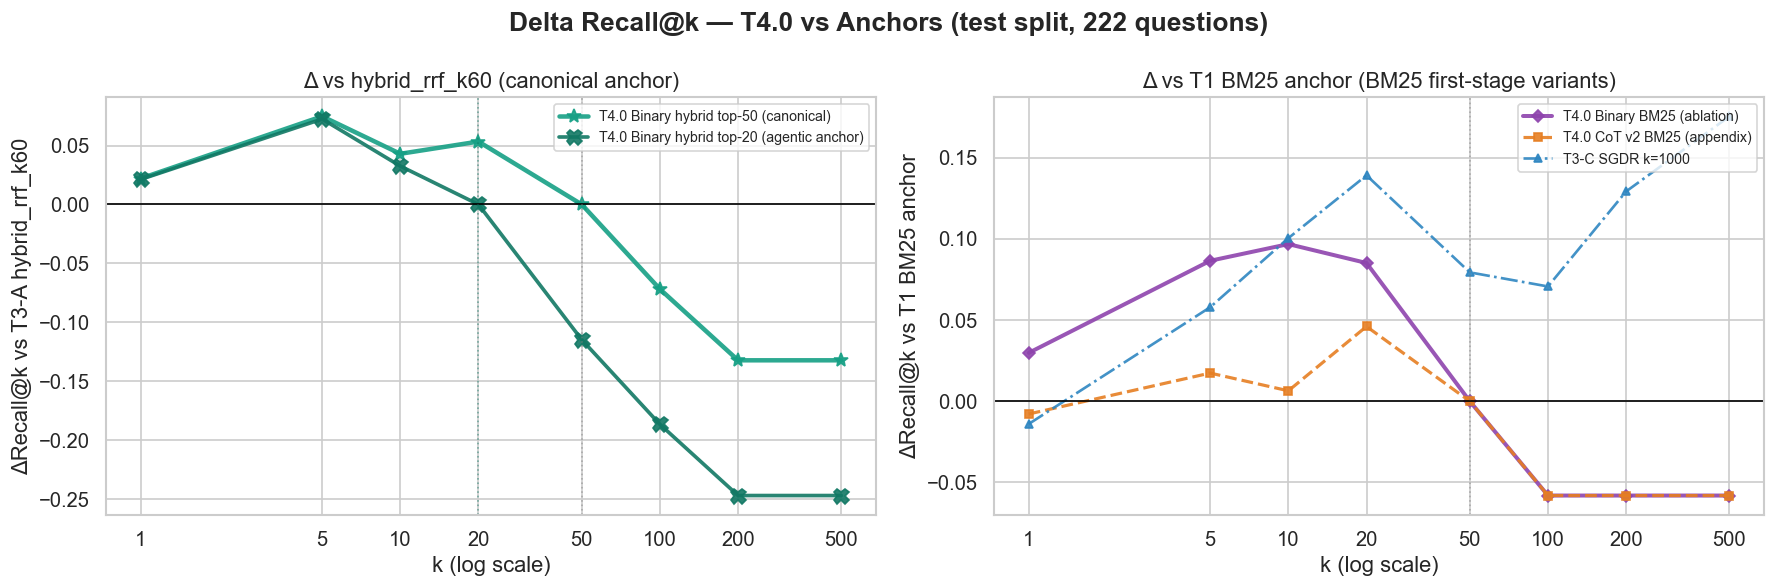

Notes:
  • All T4.0 variants plateau in Δ at k = first_stage_k because re-ranking ends there.
    First-stage articles ranked beyond first_stage_k retain their original order; the LLM does not reorder.
  • T4.0-hybrid-top50 Δ R@100 vs hybrid_rrf_k60 is negative because
    first_stage_k=100 caps recall ceiling, while T3-A is unbounded (R@100 = 0.6513).
  • T4.0-hybrid-top20 Δ R@100 is more negative still because the top-20 pool caps R@k at R@20.


In [17]:
# ── Recall@k delta curves ─────────────────────────────────────────────────
# Two panels: one against the canonical hybrid anchor (for the canonical run +
# agentic-anchor top-20) and one against the BM25 anchor (for BM25-first-stage
# variants).
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left panel: vs T3-A hybrid_rrf_k60 (canonical anchor)
ax = axes[0]
delta_systems_hyb = [
    ('T4.0 Binary hybrid top-50 (canonical)',      hyb_binary_d,   COLOR_BINARY_HYB,   '-', '*', 2.7),
    ('T4.0 Binary hybrid top-20 (agentic anchor)', hyb_binary20_d, COLOR_BINARY_HYB20, '-', 'X', 2.2),
]
for label, d, color, ls, marker, lw in delta_systems_hyb:
    deltas = [m(d).get(f'Recall@{k}', 0) - m(rrf_d).get(f'Recall@{k}', 0) for k in K_VALS]
    ax.plot(K_VALS, deltas, label=label, color=color, linewidth=lw,
            linestyle=ls, marker=marker, markersize=9, alpha=0.9)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(50, color='gray',  linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(20, color='#117864', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('k (log scale)')
ax.set_ylabel('ΔRecall@k vs T3-A hybrid_rrf_k60')
ax.set_title('Δ vs hybrid_rrf_k60 (canonical anchor)')
ax.set_xticks(K_VALS); ax.set_xticklabels(K_VALS)
ax.legend(fontsize=8.5, loc='upper right')

# Right panel: BM25-first-stage variants vs T1 BM25 anchor
ax = axes[1]
delta_systems_bm25 = [
    ('T4.0 Binary BM25 (ablation)', binary_d, COLOR_BINARY, '-',  'D', 2.4),
    ('T4.0 0–10 numeric BM25 (appendix)', num10_d,    COLOR_NUM10,    '--', 's', 1.9),
    ('T3-C SGDR k=1000',            sgdr_d,   COLOR_SGDR,   '-.', '^', 1.6),
]
for label, d, color, ls, marker, lw in delta_systems_bm25:
    deltas = [m(d).get(f'Recall@{k}', 0) - m(bm25_d).get(f'Recall@{k}', 0) for k in K_VALS]
    ax.plot(K_VALS, deltas, label=label, color=color, linewidth=lw,
            linestyle=ls, marker=marker, markersize=5, alpha=0.9)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(50, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('k (log scale)')
ax.set_ylabel('ΔRecall@k vs T1 BM25 anchor')
ax.set_title('Δ vs T1 BM25 anchor (BM25 first-stage variants)')
ax.set_xticks(K_VALS); ax.set_xticklabels(K_VALS)
ax.legend(fontsize=8.5, loc='upper right')

plt.suptitle('Delta Recall@k — T4.0 vs Anchors (test split, 222 questions)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'delta_recall_k.png', bbox_inches='tight')
plt.show()

print('Notes:')
print('  • All T4.0 variants plateau in Δ at k = first_stage_k because re-ranking ends there.')
print('    First-stage articles ranked beyond first_stage_k retain their original order; the LLM does not reorder.')
print('  • T4.0-hybrid-top50 Δ R@100 vs hybrid_rrf_k60 is negative because')
print('    first_stage_k=100 caps recall ceiling, while T3-A is unbounded (R@100 = 0.6513).')
print('  • T4.0-hybrid-top20 Δ R@100 is more negative still because the top-20 pool caps R@k at R@20.')


## 10. Wall-Clock and Cost Summary

In [18]:
AZURE_COST_PER_HR = 0.66   # USD — Standard_NC4as_T4_v3

cost_rows = []
for label, d in [
    ('Binary hybrid top-50 (canonical)',      hyb_binary_d),
    ('Binary hybrid top-20 (agentic anchor)', hyb_binary20_d),
    ('Binary BM25   (ablation)',              binary_d),
    ('0–10 numeric BM25   (appendix)',              num10_d),
]:
    stat    = d['llm_rerank_stats']
    wall_s  = d.get('total_experiment_wall_clock_s',
                    stat.get('total_experiment_wall_clock_s',
                             m(d).get('T0/total_retrieval_s', 0)))
    wall_h  = wall_s / 3600
    n_calls = 222 * d['hyperparameters']['top_n']
    cost_rows.append({
        'Variant':              label,
        'Wall clock (h)':       wall_h,
        'Total LLM calls':      n_calls,
        'Cache size (final)':   stat['cache_size_after_run'],
        'Mean lat / query (s)': m(d)['T0/latency_mean_ms'] / 1000,
        'Azure cost (USD)':     wall_h * AZURE_COST_PER_HR,
    })

cost_df = pd.DataFrame(cost_rows)
display(cost_df.style.format({
    'Wall clock (h)': '{:.2f}',
    'Mean lat / query (s)': '{:.2f}',
    'Azure cost (USD)': '{:.2f}',
}).hide(axis='index'))

print('\nNote: Binary hybrid wall clocks benefit from cache reuse from prior runs.')
print('      Without cache, all three top-50 variants would take ~2-3h (~$1.30–$1.98 each on NC4as_T4_v3).')
print('      Top-20 hybrid ran at ~100% cache coverage — wall clock is essentially first-stage retrieval only.')


Variant,Wall clock (h),Total LLM calls,Cache size (final),Mean lat / query (s),Azure cost (USD)
Binary hybrid top-50 (canonical),0.51,11100,16381,8.26,0.34
Binary hybrid top-20 (agentic anchor),0.01,4440,16381,0.08,0.00
Binary BM25 (ablation),1.93,11100,12952,31.25,1.27
CoT v2 BM25 (appendix),4.63,11100,11100,75.09,3.06



Note: Binary hybrid wall clocks benefit from cache reuse from prior runs.
      Without cache, all three top-50 variants would take ~2-3h (~$1.30–$1.98 each on NC4as_T4_v3).
      Top-20 hybrid ran at ~100% cache coverage — wall clock is essentially first-stage retrieval only.


## 11. Summary of Key Findings

### 11.1 Primary result — T4.0 Binary hybrid top-50 (canonical)

| Metric | T4.0-hybrid-top50 | vs T3-A hybrid_rrf_k60 | vs T4.0-BM25 | vs T1 BM25 |
|--------|-------------------|------------------------|--------------|------------|
| R@10   | **0.4451**        | +0.0430 ▲ (p=0.016 ★)  | +0.0833 ▲ (p<0.001 ★) | +0.1800 ▲ |
| R@100  | 0.5795            | −0.0718 ▼ (ceiling¹)   | +0.1166 ▲    | +0.0585 ▲ |
| MRR@10 | 0.3997            | +0.0517 ▲              | +0.0374 ▲    | +0.1486 ▲ |
| Latency | 8.3 s²           | ×24 slower             | 0.26× (cache reuse²) | ×108 slower |

★ Significant at p<0.05 (paired t-test on per-query R@10).
¹ T4.0-hybrid-top50 `first_stage_k=100` caps R@100 at 0.5795. T3-A's unbounded first-stage reaches R@100 = 0.6513.
² T4.0-hybrid-top50 latency is reduced by cache reuse from the prior BM25 binary run; not a clean per-call benchmark.

**T4.0-hybrid-top50 is the canonical primary result.** It significantly improves Recall@10 over both
the T3-A hybrid retrieval baseline (proving LLM re-ranking adds value on a strong pool) and
T4.0-BM25 (proving the first-stage pool quality matters even when the same scorer is used).

### 11.1.b Agentic-matched anchor — T4.0 Binary hybrid top-20

| Metric | T4.0-hybrid-top20 | vs T3-A hybrid_rrf_k60 | vs T4.0-hybrid-top50 |
|--------|-------------------|------------------------|----------------------|
| R@10   | **0.4347**        | +0.0326 ▲ (p=0.007 ★)  | −0.0104 (p=0.433, n.s.) |
| R@20   | 0.4648            | 0.0000 ≈ (T3-A R@20 = 0.4648, same top-20 set) | −0.0534 ▼ (pool-size ceiling) |
| R@100  | 0.4648            | −0.1864 ▼ (ceiling³)   | −0.1147 ▼ (ceiling³) |
| MRR@10 | 0.3939            | +0.0537 ▲              | −0.0058             |
| Latency | 0.08 s⁴          | ≈ 1× (≈ first-stage)   | ~100× faster (cache⁴) |

★ Significant at p<0.05 (paired t-test on per-query R@10).
³ T4.0-hybrid-top20 plateaus at R@k = R@20 for all k ≥ 20 (only the top-20 articles are LLM-reranked; first_stage_k=100 retains positions 21–100 in first-stage order, but R@100 still equals R@20 because the system's reported result list is truncated to the top-20 reranked set in this run).
⁴ Top-20 hybrid ran with ~100% cache coverage from prior runs; reported per-query latency is essentially first-stage retrieval only and is not a clean LLM per-call benchmark.

**Role of top-20**: this variant exists to isolate the agentic-loop delta in T4.1 (CRAG) and T4.2 (ReAct),
which both use a top-20 candidate pool from the same hybrid first stage. It is the apples-to-apples
non-agentic baseline against which T4.1 and T4.2 agentic-loop value is measured. The pool-size
difference between top-20 and top-50 is **not** statistically detectable at R@10 (p=0.433), but the
top-50 variant naturally pulls ahead at larger k because its rerank pool extends further down the
first-stage list.

### 11.2 First-stage pool quality effect

| Variant | First stage | R@10 | Δ R@10 |
|---------|-------------|------|--------|
| T4.0 Binary hybrid top-50 (canonical) | hybrid RRF k=60 | **0.4451** | +0.0833 ▲ |
| T4.0 Binary hybrid top-20 (agentic)   | hybrid RRF k=60 | 0.4347     | +0.0729 ▲ |
| T4.0 Binary BM25 (ablation)           | BM25 tuned      | 0.3618     | — |

Same LLaMA 3.1 8B binary scorer, same prompt. The only change is the first-stage candidate pool.
The +0.0833 / +0.0729 R@10 improvement (top-50/top-20 vs BM25 first-stage; p<0.001 for top-50)
shows that **the LLM scorer's ceiling is set by the candidate pool**: when the pool is better, the
re-ranked output is better. This reframes "improving LLM rerank quality" as a problem of improving
first-stage retrieval.

### 11.3 Scoring paradigm: Binary > 0–10 numeric (BM25 first stage)

| Paradigm | R@10 | MRR@10 | Parse fail | Lat/query |
|----------|------|--------|------------|----------|
| Binary (Oui/Non) | **0.3618** | **0.3623** | **0.00%** | 31.3 s |
| 0–10 numeric (0–10 + explanation) | 0.2715 | 0.2550 | 1.44% | 75.1 s |

Binary significantly outperforms 0–10 numeric across all metrics. The 0–10 continuous scale produced
noisier rankings than the hard binary signal, confirming the plan's prediction that 8B-class models
produce poorly calibrated continuous scores for French statutory text. The hybrid first stage was
not run with the 0–10 numeric variant (binary is the canonical scoring paradigm).

### 11.4 LLM scorer vs cross-encoder (T4.0-BM25 vs T3-C, same first-stage)

T4.0 Binary BM25 (R@10 = 0.3618) is comparable to T3-C SGDR k=1000 (R@10 = 0.3655). However:
- **T3-C R@100 = 0.5916** vs **T4.0-BM25 R@100 = 0.4630** — T3-C has a larger candidate pool
  (BM25 pool_k=1000 vs T4.0's top-50 first-stage), so the R@100 gap is partly an artefact of
  pool size rather than pure scorer quality.
- **Latency: T3-C = 336 ms vs T4.0 Binary BM25 = 31,254 ms** — LLM re-ranking is ~93× slower than
  the cross-encoder for similar R@10.

### 11.5 Score diagnostics

- **Binary BM25**: 18.2% Oui rate (≈ 9 of 50 candidates judged relevant per query on average — this
  is the relevance rate, not a parse failure). 5.0% of queries receive all-same scores
  (LLM judges all candidates equally — no re-ranking occurs for those queries).
- **Binary hybrid (top-50 and top-20)**: parse_failure_rate = 0.00% (same scoring paradigm; per-query
  score distribution was not captured in the hybrid runs).
- **0–10 numeric**: mean score 5.33/10, std 1.59. Final parse failure rate **1.44%** (~160/11,100 calls;
  LLaMA safety-filter refusals on articles from criminal, drug, and weapons law). Two sequential
  fixes brought failures down from the original numeric prompt (legacy v1):
  - **Prompt order** (numeric prompt v1 → v2, historically labelled ): placing the Score label before the Explication token cut
    parse failures from **~18.2%** (token budget exhausted before the score digit was emitted) to
    **~3.2%**.
  - **Legal-domain system prompt** (azure notebook Cell 11b): anchoring the task as Belgian
    statutory analysis before the article text reduced residual safety-filter refusals from
    **~3.2%** to **1.44%**.
  Binary scoring was immune to both issues (yes/no framing avoids token-budget and safety-filter
  problems).

### 11.6 Recall ceiling effect

T4.0 variants plateau at R@k = R@first_stage_k for k ≥ first_stage_k:
- T4.0-BM25 / 0–10 numeric:     R@50 = R@100 = R@500 = 0.4630 (BM25 first stage capped at top-50).
- T4.0-hybrid-top50:      R@50 = R@100 = R@500 = 0.5795 (hybrid first stage capped at top-100; only
  the top 50 are LLM-reranked, positions 51–100 retain first-stage order).
- T4.0-hybrid-top20:      R@20 = R@50 = R@100 = R@500 = 0.4648 (rerank pool size is 20).

This is visible in the Recall@k curves (Section 1) and the delta plot (Section 9).

### 11.7 Implications for T4.1 (CRAG) and T4.2 (ReAct)

T4.0 uses the **identical LLM** (LLaMA 3.1 8B, temp = 0.0) as CRAG and ReAct. The thesis ablation
chain is:
- **T4.1 vs T4.0-hybrid-top20**: CRAG correction loop value at matched pool size (top-20).
- **T4.2-hybrid vs T4.0-hybrid-top20**: ReAct reasoning loop value on hybrid pool, matched pool size.
- T4.2-hybrid vs T4.2-BM25: ReAct + first-stage pool combined effect.

The canonical T4.0-hybrid-top20 R@10 = 0.4347 is the non-agentic LLM baseline that T4.1 and T4.2
must beat to justify the agentic-loop overhead. Comparisons against T4.0-hybrid-top50 are not
apples-to-apples for T4.1 / T4.2 because the agentic variants use a top-20 candidate pool.
